### The goal of this notebook is to test various simulation methods, as well as to cluster final conformations to compare methods.

In [2]:
import numpy as np  # Numerical operations and array manipulations
import matplotlib.pyplot as plt  # Plotting and data visualization
import pandas as pd  # Data structures for handling data (e.g., DataFrame)
import visualization_functions as vis # our functions for visualization
import sim_methods as sim # our functions for simulation
import structureLibrary  as struc

import importlib
importlib.reload(sim)
importlib.reload(vis)
importlib.reload(struc)

def averageEnergies(arr, mode='mean', min_count_frac=None):
    max_len = max(len(a) for a in arr)

    padded = np.full((len(arr), max_len), np.nan)

    for j, a in enumerate(arr):
        padded[j, :len(a)] = a

    if mode == 'mean':
        means = np.nanmean(padded, axis=0)
    elif mode == 'median':
        means = np.nanmedian(padded, axis=0)
    else:
        return

    if min_count_frac is not None:
        # runs converge/stop at different steps, so later steps are averaged over fewer
        # and fewer runs. Blank out (NaN -> no line drawn) any step where the number of
        # still-contributing runs has dropped below min_count_frac of the starting count.
        counts = np.sum(~np.isnan(padded), axis=0)
        means[counts < min_count_frac * len(arr)] = np.nan

    return means

def averageDeltaEnergies(arr, mode='mean'):
    diffs = [np.diff(a) for a in arr]

    max_len = max(len(d) for d in diffs)

    padded = np.full((len(diffs), max_len), np.nan)

    for j, d in enumerate(diffs):
        padded[j, :len(d)] = d

    if mode == 'mean':
        means = np.nanmean(padded, axis=0)
    elif mode == 'median':
        means = np.nanmedian(padded, axis=0)
    else:
        return
    
    return means

### Load structure we want to simulate

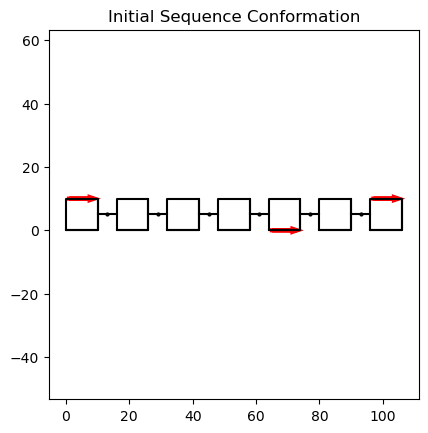

In [ ]:
# Load structure to simulate

# shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
#           'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

shapes = struc.structureLibrary('stutter trap') # can be 'original', 'original_8', 'diamond', 'six ring', 'zipper', 'two domain', 'alt corners', 'backbone', 'end-middle', 'sym frustration', 'three domain', 'alt dipole', 'dumbbell', 'greedy trap', 'spiral trap', 'short trap', or 'stutter trap'
perturbed = struc.perturb_structure(shapes,patch_offset_mean=0,patch_offset_std=1,hinge_bar_radius=0.6, hinge_gap=1.5, hinge_steric_clearance=0.5, hinge_left_offset=3.8, hinge_rotation_mean=0,hinge_rotation_std=10)

perturb_kwargs = {'patch_offset_mean': 0, 'patch_offset_std': 1, 'hinge_bar_radius': 0.6, 'hinge_gap': 1.5, 'hinge_steric_clearance': 0.5, 'hinge_left_offset':3.8, 'hinge_rotation_mean': 0,'hinge_rotation_std': 10}
# random fabrication stops on ~30% of hinges, ~25° +/- 10° of one-sided travel
limit_kwargs = {'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}
# or pin hinge 3 to +/-5 deg and cap hinge 6 to the 180-250 band, plus random stops elsewhere:
# limit_kwargs = {'intentional': {3: 5, 6: (180, 250)}, 'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}


hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)
# hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(perturbed)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
#m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes
m = np.array([7.25e-7]*sum(patch_num))

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

### Save animations or plots

In [12]:
limit_kwargs = {'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}
#limit_kwargs = {'intentional': {3: 5, 6: (180, 250)}, 'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}

# sim to save animations or make plots
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 3 # number of simulations
final_hinges, final_es, energies = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, plot=False, shapes=shapes) #, perturb_kwargs=perturb_kwargs, limit_kwargs=limit_kwargs)
final_hinges, final_es, energies = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, plot=False, shapes=shapes) #, perturb_kwargs=perturb_kwargs, limit_kwargs=limit_kwargs)
final_hinges, final_es, energies = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, plot=False, shapes=shapes) #, perturb_kwargs=perturb_kwargs, limit_kwargs=limit_kwargs)
final_hinges, final_es, energies = sim.sim_many(nsim, 'hybrid',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, plot=False, shapes=shapes) #, perturb_kwargs=perturb_kwargs, limit_kwargs=limit_kwargs)

### Simulating many times

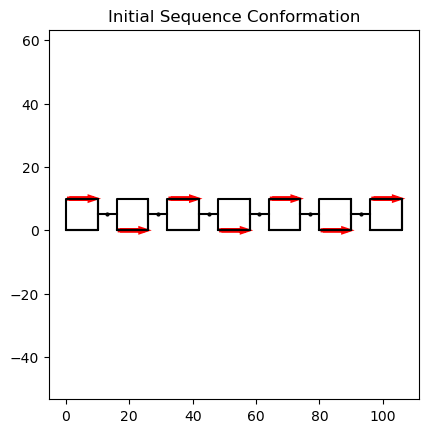

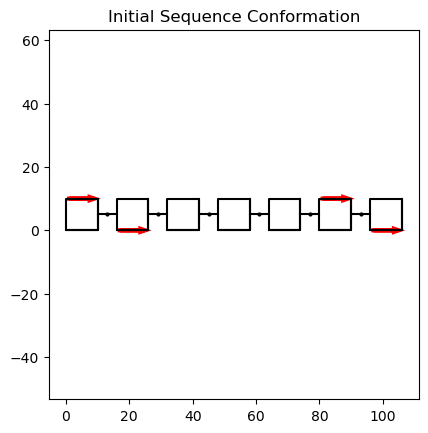

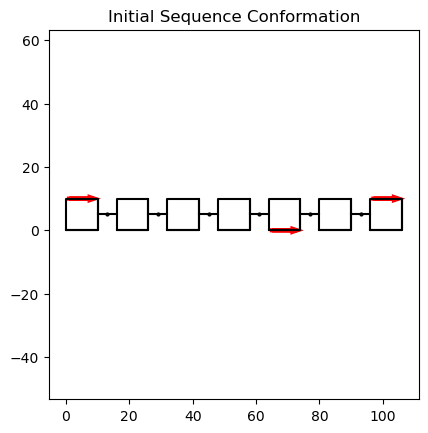

In [ ]:
# Load structure to simulate

# shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
#           'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

shapes = struc.structureLibrary('spiral trap') # can be 'original', 'original_8', 'diamond', 'six ring', 'zipper', 'two domain', 'alt corners', 'backbone', 'end-middle', 'sym frustration', 'three domain', 'alt dipole', 'dumbbell', 'greedy trap'
perturbed = struc.perturb_structure(shapes,patch_offset_mean=0,patch_offset_std=1,hinge_bar_radius=0.6, hinge_gap=1.5, hinge_steric_clearance=0.5, hinge_left_offset=3.8, hinge_rotation_mean=0,hinge_rotation_std=10)

perturb_kwargs = {'patch_offset_mean': 0, 'patch_offset_std': 1, 'hinge_bar_radius': 0.6, 'hinge_gap': 1.5, 'hinge_steric_clearance': 0.5, 'hinge_left_offset':3.8, 'hinge_rotation_mean': 0,'hinge_rotation_std': 10}
# random fabrication stops on ~30% of hinges, ~25° +/- 10° of one-sided travel
limit_kwargs = {'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}
# or pin hinge 3 to +/-5 deg and cap hinge 6 to the 180-250 band, plus random stops elsewhere:
# limit_kwargs = {'intentional': {3: 5, 6: (180, 250)}, 'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}


hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)
# hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(perturbed)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
#m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes
m = np.array([7.25e-7]*sum(patch_num))

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)


# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_hy, final_es_hy, energies_hy = sim.sim_many(nsim,'hybrid',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)

np.save("Data/trapValidation/spiral/energies_gd_100", energies_gd)
np.save("Data/trapValidation/spiral/energies_mc_100", energies_mc)
np.save("Data/trapValidation/spiral/energies_ws_100_claude", energies_ws)
np.save("Data/trapValidation/spiral/energies_hy_100", energies_hy)

np.save("Data/trapValidation/spiral/final_es_gd_100", final_es_gd)
np.save("Data/trapValidation/spiral/final_es_mc_100", final_es_mc)
np.save("Data/trapValidation/spiral/final_es_ws_100_claude", final_es_ws)
np.save("Data/trapValidation/spiral/final_es_hy_100", final_es_hy)

np.save("Data/trapValidation/spiral/final_hinges_gd_100", final_hinges_gd)
np.save("Data/trapValidation/spiral/final_hinges_mc_100", final_hinges_mc)
np.save("Data/trapValidation/spiral/final_hinges_ws_100_claude", final_hinges_ws)
np.save("Data/trapValidation/spiral/final_hinges_hy_100", final_hinges_hy)



# Load structure to simulate

# shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
#           'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

shapes = struc.structureLibrary('short trap') # can be 'original', 'original_8', 'diamond', 'six ring', 'zipper', 'two domain', 'alt corners', 'backbone', 'end-middle', 'sym frustration', 'three domain', 'alt dipole', 'dumbbell', 'greedy trap'
perturbed = struc.perturb_structure(shapes,patch_offset_mean=0,patch_offset_std=1,hinge_bar_radius=0.6, hinge_gap=1.5, hinge_steric_clearance=0.5, hinge_left_offset=3.8, hinge_rotation_mean=0,hinge_rotation_std=10)

perturb_kwargs = {'patch_offset_mean': 0, 'patch_offset_std': 1, 'hinge_bar_radius': 0.6, 'hinge_gap': 1.5, 'hinge_steric_clearance': 0.5, 'hinge_left_offset':3.8, 'hinge_rotation_mean': 0,'hinge_rotation_std': 10}
# random fabrication stops on ~30% of hinges, ~25° +/- 10° of one-sided travel
limit_kwargs = {'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}
# or pin hinge 3 to +/-5 deg and cap hinge 6 to the 180-250 band, plus random stops elsewhere:
# limit_kwargs = {'intentional': {3: 5, 6: (180, 250)}, 'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}


hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)
# hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(perturbed)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
#m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes
m = np.array([7.25e-7]*sum(patch_num))

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)


# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_hy, final_es_hy, energies_hy = sim.sim_many(nsim,'hybrid',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)


np.save("Data/trapValidation/short/energies_gd_100", energies_gd)
np.save("Data/trapValidation/short/energies_mc_100", energies_mc)
np.save("Data/trapValidation/short/energies_ws_100_claude", energies_ws)
np.save("Data/trapValidation/short/energies_hy_100", energies_hy)

np.save("Data/trapValidation/short/final_es_gd_100", final_es_gd)
np.save("Data/trapValidation/short/final_es_mc_100", final_es_mc)
np.save("Data/trapValidation/short/final_es_ws_100_claude", final_es_ws)
np.save("Data/trapValidation/short/final_es_hy_100", final_es_hy)

np.save("Data/trapValidation/short/final_hinges_gd_100", final_hinges_gd)
np.save("Data/trapValidation/short/final_hinges_mc_100", final_hinges_mc)
np.save("Data/trapValidation/short/final_hinges_ws_100_claude", final_hinges_ws)
np.save("Data/trapValidation/short/final_hinges_hy_100", final_hinges_hy)





# Load structure to simulate

# shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
#           'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

shapes = struc.structureLibrary('stutter trap') # can be 'original', 'original_8', 'diamond', 'six ring', 'zipper', 'two domain', 'alt corners', 'backbone', 'end-middle', 'sym frustration', 'three domain', 'alt dipole', 'dumbbell', 'greedy trap'
perturbed = struc.perturb_structure(shapes,patch_offset_mean=0,patch_offset_std=1,hinge_bar_radius=0.6, hinge_gap=1.5, hinge_steric_clearance=0.5, hinge_left_offset=3.8, hinge_rotation_mean=0,hinge_rotation_std=10)

perturb_kwargs = {'patch_offset_mean': 0, 'patch_offset_std': 1, 'hinge_bar_radius': 0.6, 'hinge_gap': 1.5, 'hinge_steric_clearance': 0.5, 'hinge_left_offset':3.8, 'hinge_rotation_mean': 0,'hinge_rotation_std': 10}
# random fabrication stops on ~30% of hinges, ~25° +/- 10° of one-sided travel
limit_kwargs = {'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}
# or pin hinge 3 to +/-5 deg and cap hinge 6 to the 180-250 band, plus random stops elsewhere:
# limit_kwargs = {'intentional': {3: 5, 6: (180, 250)}, 'stop_prob': 0.3, 'stop_mean': 25, 'stop_std': 10}


hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)
# hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(perturbed)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
#m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes
m = np.array([7.25e-7]*sum(patch_num))

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)
final_hinges_hy, final_es_hy, energies_hy = sim.sim_many(nsim,'hybrid',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes)



np.save("Data/trapValidation/stutter/energies_gd_100", energies_gd)
np.save("Data/trapValidation/stutter/energies_mc_100", energies_mc)
np.save("Data/trapValidation/stutter/energies_ws_100_claude", energies_ws)
np.save("Data/trapValidation/stutter/energies_hy_100", energies_hy)

np.save("Data/trapValidation/stutter/final_es_gd_100", final_es_gd)
np.save("Data/trapValidation/stutter/final_es_mc_100", final_es_mc)
np.save("Data/trapValidation/stutter/final_es_ws_100_claude", final_es_ws)
np.save("Data/trapValidation/stutter/final_es_hy_100", final_es_hy)

np.save("Data/trapValidation/stutter/final_hinges_gd_100", final_hinges_gd)
np.save("Data/trapValidation/stutter/final_hinges_mc_100", final_hinges_mc)
np.save("Data/trapValidation/stutter/final_hinges_ws_100_claude", final_hinges_ws)
np.save("Data/trapValidation/stutter/final_hinges_hy_100", final_hinges_hy)


In [ ]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)
final_hinges_hy, final_es_hy, energies_hy = sim.sim_many(nsim,'hybrid',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)

In [21]:
# save energies, hinges

np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_gd_100", energies_gd)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_mc_100", energies_mc)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_ws_100_claude", energies_ws)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_hy_100", energies_hy)

np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_gd_100", final_es_gd)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_mc_100", final_es_mc)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_ws_100_claude", final_es_ws)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_hy_100", final_es_hy)

np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_gd_100", final_hinges_gd)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_mc_100", final_hinges_mc)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_ws_100_claude", final_hinges_ws)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_hy_100", final_hinges_hy)

In [22]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)
final_hinges_hy, final_es_hy, energies_hy = sim.sim_many(nsim,'hybrid',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=False, shapes=shapes, perturb_kwargs=perturb_kwargs)

In [23]:
# save energies, hinges

np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_gd_1000", energies_gd)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_mc_1000", energies_mc)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_ws_1000_claude", energies_ws)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/energies_hy_1000", energies_hy)

np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_gd_1000", final_es_gd)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_mc_1000", final_es_mc)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_ws_1000_claude", final_es_ws)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_es_hy_1000", final_es_hy)

np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_gd_1000", final_hinges_gd)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_mc_1000", final_hinges_mc)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_ws_1000_claude", final_hinges_ws)
np.save("Data/fabUncertainty/0_1_0.6_1.5_0.5_3.8_0_10/final_hinges_hy_1000", final_hinges_hy)

### Load previously saved data

In [30]:
# load energies
energies_gd = np.load("Data/trapValidation/stutter/energies_gd_100.npy", allow_pickle=True)
energies_mc = np.load("Data/trapValidation/stutter/energies_mc_100.npy", allow_pickle=True)
energies_ws = np.load("Data/trapValidation/stutter/energies_ws_100_claude.npy", allow_pickle=True)
energies_hy = np.load("Data/trapValidation/stutter/energies_hy_100.npy", allow_pickle=True)

final_es_gd = np.load("Data/trapValidation/stutter/final_es_gd_100.npy", allow_pickle=True)
final_es_mc = np.load("Data/trapValidation/stutter/final_es_mc_100.npy", allow_pickle=True)
final_es_ws = np.load("Data/trapValidation/stutter/final_es_ws_100_claude.npy", allow_pickle=True)
final_es_hy = np.load("Data/trapValidation/stutter/final_es_hy_100.npy", allow_pickle=True)

final_hinges_gd = np.load("Data/trapValidation/stutter/final_hinges_gd_100.npy", allow_pickle=True)
final_hinges_mc = np.load("Data/trapValidation/stutter/final_hinges_mc_100.npy", allow_pickle=True)
final_hinges_ws = np.load("Data/trapValidation/stutter/final_hinges_ws_100_claude.npy", allow_pickle=True)
final_hinges_hy = np.load("Data/trapValidation/stutter/final_hinges_hy_100.npy", allow_pickle=True)

### Energy analysis

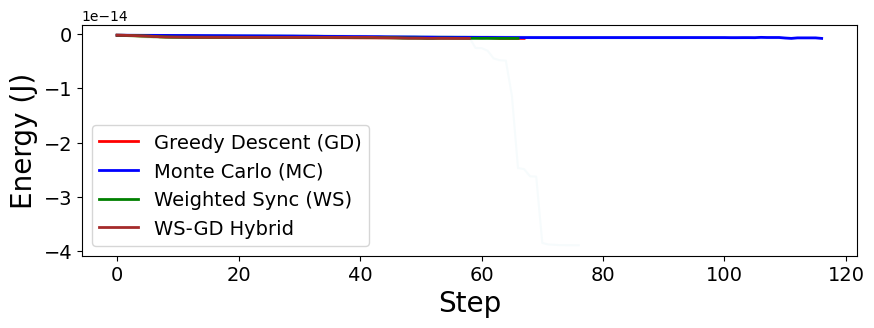

In [18]:
# plot every individual GD trajectory faintly in the background, so we can see run-to-run spread (using median as solid line)
plt.figure(figsize=(10,3))
for i in range(len(energies_gd)):
    plt.plot(energies_gd[i],c='pink',alpha=0.1)

# same for every individual MC trajectory
for i in range(len(energies_mc)):
    plt.plot(energies_mc[i],c='lightblue', alpha=0.1)

# same for every individual WS trajectory
for i in range(len(energies_ws)):
    plt.plot(energies_ws[i],c='lightgreen', alpha = 0.1)

for i in range(len(energies_hy)):
    plt.plot(energies_hy[i],c='tan', alpha = 0.1)

# overlay the across-run average trajectory for each method, drawn bold/opaque on top.
# min_count_frac=0.05 truncates each median once fewer than 5% of that method's runs
# are still contributing, so the bold line doesn't trail off into a handful of runs.
plt.plot(averageEnergies(energies_gd, mode='median', min_count_frac=0.01),c='r',lw=2, label="Greedy Descent (GD)")
plt.plot(averageEnergies(energies_mc, mode='median', min_count_frac=0.01),c='b',lw=2, label="Monte Carlo (MC)")
plt.plot(averageEnergies(energies_ws, mode='median', min_count_frac=0.01),c='g',lw=2, label="Weighted Sync (WS)")
plt.plot(averageEnergies(energies_hy, mode='median', min_count_frac=0.01),c='brown',lw=2, label="WS-GD Hybrid")

plt.xlabel("Step", fontsize=20)
plt.ylabel("Energy (J)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.ylim(-1e-12,1e-13)
plt.legend(fontsize=14)

Text(0, 0.5, 'Energy (J)')

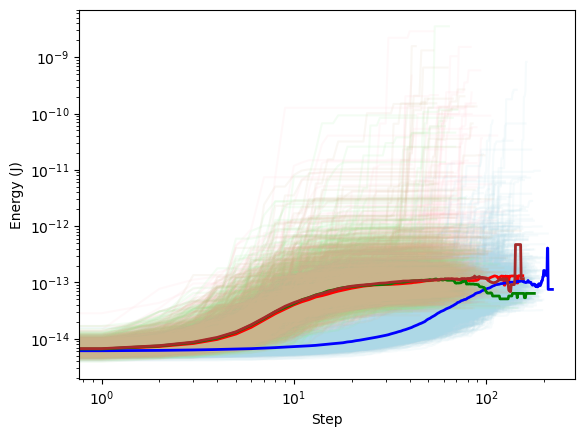

In [61]:
# same as above, but log-log plot

for i in range(len(energies_gd)):
    plt.loglog(np.abs(energies_gd[i]),c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.loglog(np.abs(energies_mc[i]),c='lightblue',alpha=0.1)

for i in range(len(energies_ws)):
    plt.loglog(np.abs(energies_ws[i]),c='lightgreen',alpha=0.1)

for i in range(len(energies_hy)):
    plt.loglog(np.abs(energies_hy[i]),c='tan',alpha=0.1)

plt.loglog(np.abs(averageEnergies(energies_gd, mode='median')),c='r',lw=2)
plt.loglog(np.abs(averageEnergies(energies_mc, mode='median')),c='b',lw=2)
plt.loglog(np.abs(averageEnergies(energies_ws, mode='median')),c='g',lw=2)
plt.loglog(np.abs(averageEnergies(energies_hy, mode='median')),c='brown',lw=2)

plt.xlabel("Step")
plt.ylabel("Energy (J)")

(array([1.e-17, 1.e-16, 1.e-15, 1.e-14, 1.e-13, 1.e-12, 1.e-11]),
 [Text(0, 1e-17, '$\\mathdefault{10^{-17}}$'),
  Text(0, 1e-16, '$\\mathdefault{10^{-16}}$'),
  Text(0, 1e-15, '$\\mathdefault{10^{-15}}$'),
  Text(0, 1e-14, '$\\mathdefault{10^{-14}}$'),
  Text(0, 1e-13, '$\\mathdefault{10^{-13}}$'),
  Text(0, 1e-12, '$\\mathdefault{10^{-12}}$'),
  Text(0, 1e-11, '$\\mathdefault{10^{-11}}$')])

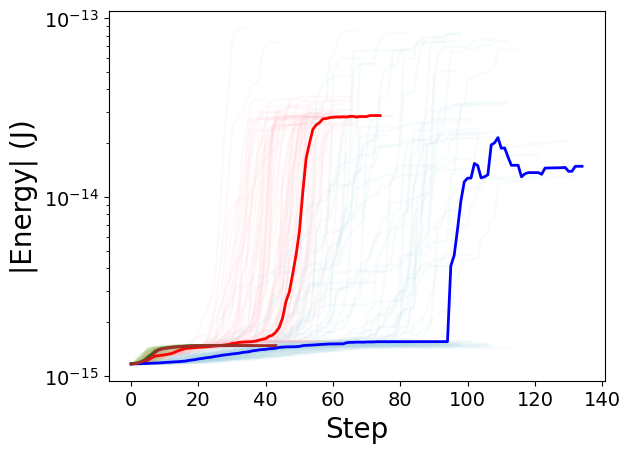

In [13]:
# same as above, but semilogy

for i in range(len(energies_gd)):
    plt.semilogy(np.abs(energies_gd[i]),c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.semilogy(np.abs(energies_mc[i]),c='lightblue',alpha=0.1)

for i in range(len(energies_ws)):
    plt.semilogy(np.abs(energies_ws[i]),c='lightgreen',alpha=0.1)

for i in range(len(energies_hy)):
    plt.semilogy(np.abs(energies_hy[i]),c='tan',alpha=0.1)

plt.semilogy(np.abs(averageEnergies(energies_gd, mode='median')),c='r',lw=2)
plt.semilogy(np.abs(averageEnergies(energies_mc, mode='median')),c='b',lw=2)
plt.semilogy(np.abs(averageEnergies(energies_ws, mode='median')),c='g',lw=2)
plt.semilogy(np.abs(averageEnergies(energies_hy, mode='median')),c='brown',lw=2)

plt.xlabel("Step", fontsize=20)
plt.ylabel("|Energy| (J)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

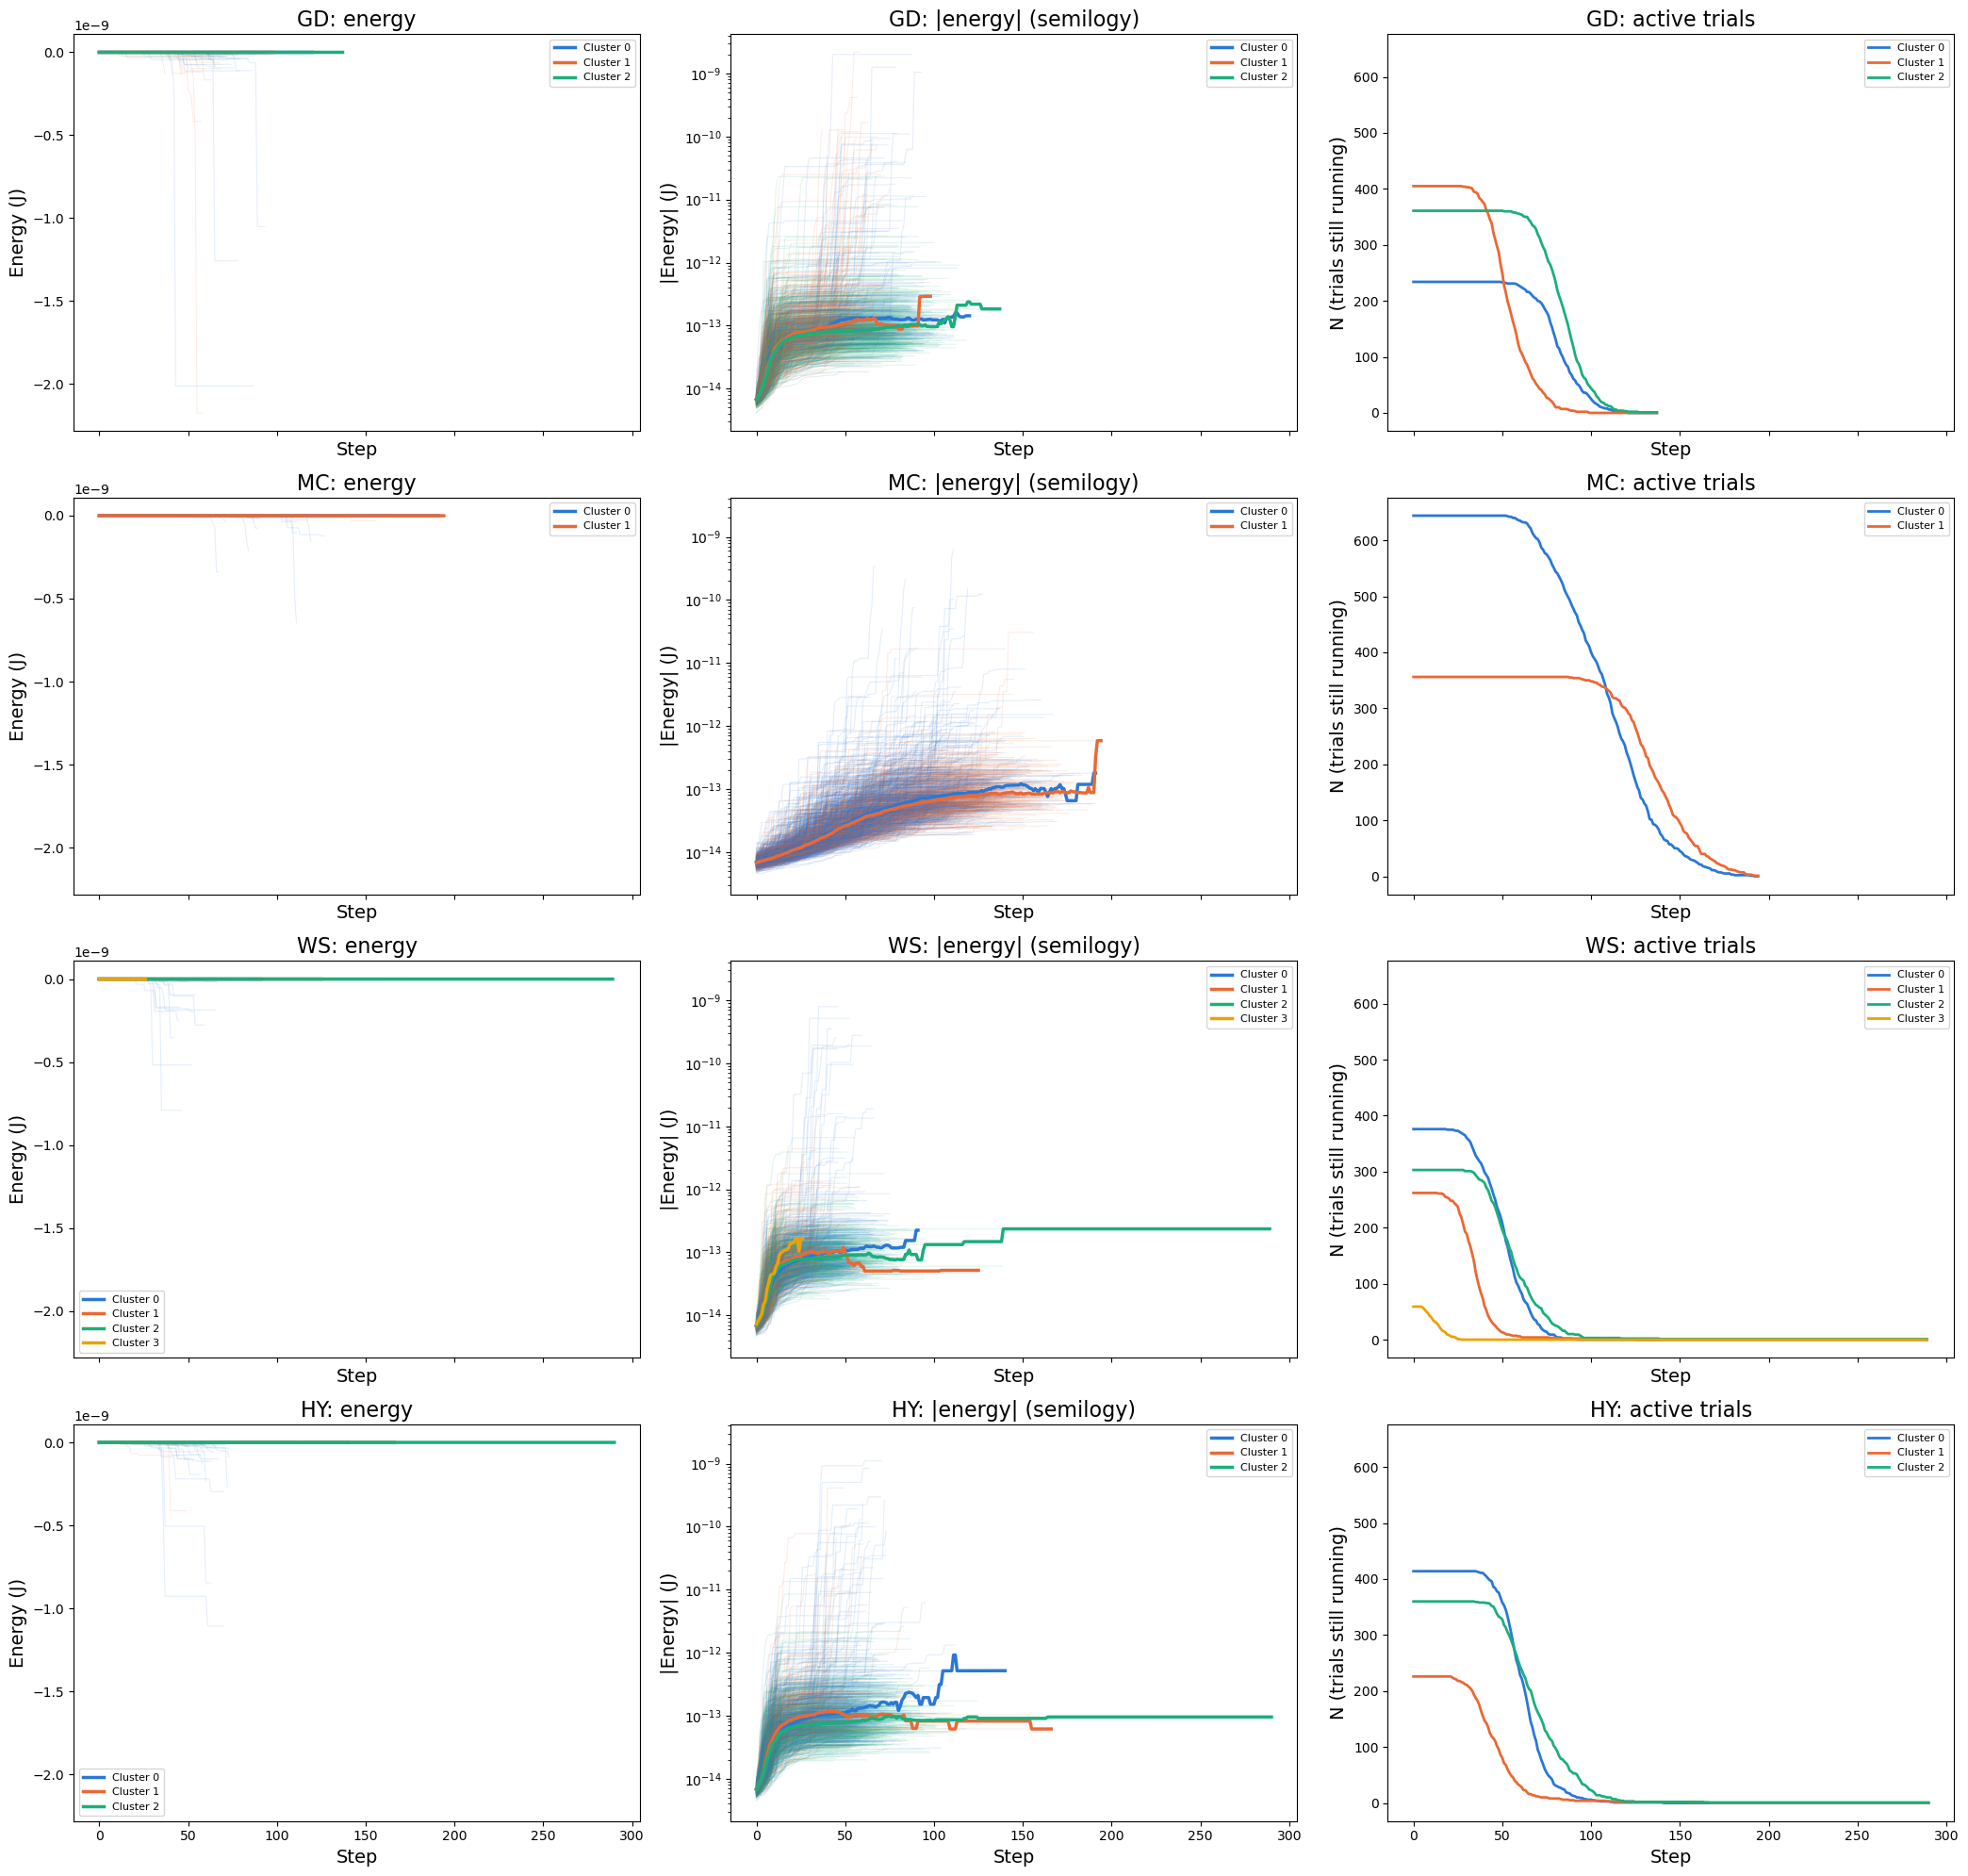

In [5]:
# Color individual trajectories by the population (KMeans cluster of final hinge angles) each run
# ends up in, using the same vis.cluster_num / vis.min_cluster_centers pipeline used later in this
# notebook. Reclustered here (rather than reusing cluster_labels_gd/mc/ws/hy from below) because
# those were computed on different simulation runs, not index-aligned with energies_gd/mc/ws/hy.

# fixed-order, colorblind-safe categorical palette
cluster_colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

cluster_max = 6
states = 10

def cluster_populations(final_hinges, final_es):
    clusternumber = vis.cluster_num(final_hinges, cluster_max, states, Plot=False)
    _, raw_labels, clusternumber = vis.min_cluster_centers(final_hinges, clusternumber, final_es)
    # remap so cluster 0 = lowest mean final energy, cluster 1 = next, etc. - KMeans label order
    # is otherwise arbitrary, so this keeps "cluster k" (and its color) meaning the same energy
    # rank in every method's plot
    mean_e = [np.mean(final_es[raw_labels == k]) for k in range(clusternumber)]
    rank_of = {old_k: rank for rank, old_k in enumerate(np.argsort(mean_e))}
    cluster_labels = np.array([rank_of[k] for k in raw_labels])
    return cluster_labels, clusternumber

cluster_labels_gd_pop, nclusters_gd_pop = cluster_populations(final_hinges_gd, final_es_gd)
cluster_labels_mc_pop, nclusters_mc_pop = cluster_populations(final_hinges_mc, final_es_mc)
cluster_labels_ws_pop, nclusters_ws_pop = cluster_populations(final_hinges_ws, final_es_ws)
cluster_labels_hy_pop, nclusters_hy_pop = cluster_populations(final_hinges_hy, final_es_hy)

fig, axes = plt.subplots(4, 3, figsize=(21, 20), sharex='col', sharey='col')

def plot_populations(ax, energies, cluster_labels, nclusters, title):
    # faint individual trajectories, colored by their cluster
    for i in range(len(energies)):
        ax.plot(energies[i], c=cluster_colors[cluster_labels[i] % len(cluster_colors)], alpha=0.12, lw=0.8)
    # bold median trajectory per cluster, drawn on top
    for k in range(nclusters):
        cluster_energies = [energies[i] for i in range(len(energies)) if cluster_labels[i] == k]
        median_traj = averageEnergies(cluster_energies, mode='median')
        ax.plot(median_traj, c=cluster_colors[k % len(cluster_colors)], lw=2.5, label=f"Cluster {k}")
    ax.set_title(f"{title}: energy", fontsize=16)
    ax.set_xlabel("Step", fontsize=14)
    ax.set_ylabel("Energy (J)", fontsize=14)
    ax.legend(fontsize=8)

def plot_populations_semilogy(ax, energies, cluster_labels, nclusters, title):
    # same as plot_populations but |energy| on a log y-axis, matching the semilogy cell below
    for i in range(len(energies)):
        ax.semilogy(np.abs(energies[i]), c=cluster_colors[cluster_labels[i] % len(cluster_colors)], alpha=0.12, lw=0.8)
    for k in range(nclusters):
        cluster_energies = [energies[i] for i in range(len(energies)) if cluster_labels[i] == k]
        median_traj = averageEnergies(cluster_energies, mode='median')
        ax.semilogy(np.abs(median_traj), c=cluster_colors[k % len(cluster_colors)], lw=2.5, label=f"Cluster {k}")
    ax.set_title(f"{title}: |energy| (semilogy)", fontsize=16)
    ax.set_xlabel("Step", fontsize=14)
    ax.set_ylabel("|Energy| (J)", fontsize=14)
    ax.legend(fontsize=8)

def plot_cluster_counts(ax, energies, cluster_labels, nclusters, title):
    # runs converge (and stop) at different steps, so per-cluster trial counts
    # decay over the course of a run rather than staying flat at their starting n
    max_len = max(len(e) for e in energies)
    for k in range(nclusters):
        lengths = np.array([len(energies[i]) for i in range(len(energies)) if cluster_labels[i] == k])
        counts = np.array([(lengths > step).sum() for step in range(max_len)])
        ax.plot(counts, c=cluster_colors[k % len(cluster_colors)], lw=2, label=f"Cluster {k}")
    ax.set_title(f"{title}: active trials", fontsize=16)
    ax.set_xlabel("Step", fontsize=14)
    ax.set_ylabel("N (trials still running)", fontsize=14)
    ax.legend(fontsize=8)

for row, (energies, cluster_labels, nclusters, title) in enumerate([
    (energies_gd, cluster_labels_gd_pop, nclusters_gd_pop, "GD"),
    (energies_mc, cluster_labels_mc_pop, nclusters_mc_pop, "MC"),
    (energies_ws, cluster_labels_ws_pop, nclusters_ws_pop, "WS"),
    (energies_hy, cluster_labels_hy_pop, nclusters_hy_pop, "HY"),
]):
    plot_populations(axes[row, 0], energies, cluster_labels, nclusters, title)
    plot_populations_semilogy(axes[row, 1], energies, cluster_labels, nclusters, title)
    plot_cluster_counts(axes[row, 2], energies, cluster_labels, nclusters, title)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

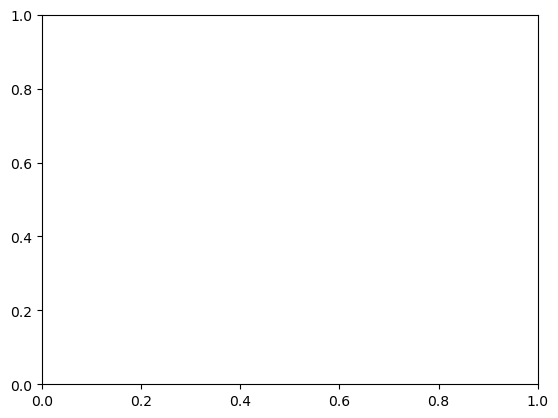

In [27]:
# plot energy distribution histograms, both for auto-binning and for set equal bins
plt.hist(final_es_gd,bins='auto',color="red", alpha=0.5)
plt.hist(final_es_hy,bins='auto',color="brown", alpha=0.5)
plt.hist(final_es_mc,bins='auto',color="blue", alpha=0.5)
plt.hist(final_es_ws,bins='auto',color="green", alpha=0.5)
plt.xlabel("Energy")

plt.show()

bin_num = 20
plt.hist(final_es_gd,bins=bin_num,color="red", alpha=0.5)
plt.hist(final_es_hy,bins=bin_num,color="brown", alpha=0.5)
plt.hist(final_es_mc,bins=bin_num,color="blue", alpha=0.5)
plt.hist(final_es_ws,bins=bin_num,color="green", alpha=0.5)
plt.xlabel("Energy")

plt.show()


=== GD: 4 run(s) with final energy within 3.0e-08 J of -1.0e-07 J ===
Cluster assignment of these runs: {1: 4}


,run,energy (J),cluster,cluster mean energy (J),biggest-deviation hinge(s),deviation (deg)
0,64,-1.051250e-07,1,-3.352648e-08,"[4, 5]","[3.62, 1.63]"
1,95,-1.051250e-07,1,-3.352648e-08,"[4, 5]","[4.44, 2.0]"
2,86,-9.709409e-08,1,-3.364816e-08,"[4, 5]","[3.33, 1.51]"
3,79,-7.825073e-08,1,-3.393367e-08,"[4, 5]","[3.48, 1.58]"



=== MC: 2 run(s) with final energy within 3.0e-08 J of -1.0e-07 J ===
Cluster assignment of these runs: {0: 1, 1: 1}


,run,energy (J),cluster,cluster mean energy (J),biggest-deviation hinge(s),deviation (deg)
0,33,-1.051250e-07,0,-1.519530e-08,"[4, 8]","[1.74, 0.46]"
1,85,-7.962769e-08,1,-9.181661e-09,"[9, 7]","[46.53, 20.81]"



=== WS: 0 run(s) with final energy within 3.0e-08 J of -1.0e-07 J ===

=== HY: 2 run(s) with final energy within 3.0e-08 J of -1.0e-07 J ===
Cluster assignment of these runs: {0: 2}


,run,energy (J),cluster,cluster mean energy (J),biggest-deviation hinge(s),deviation (deg)
0,94,-8.429987e-08,0,-2.315554e-08,"[4, 6]","[0.11, 0.1]"
1,44,-7.537335e-08,0,-2.324662e-08,"[6, 5]","[0.1, 0.05]"


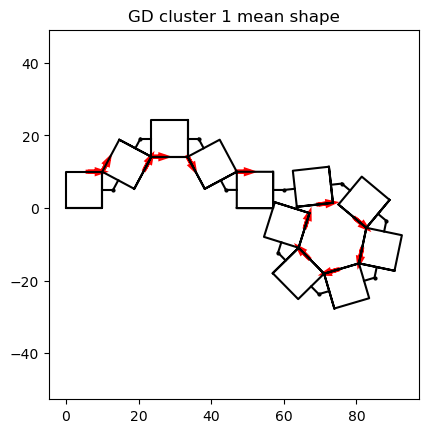

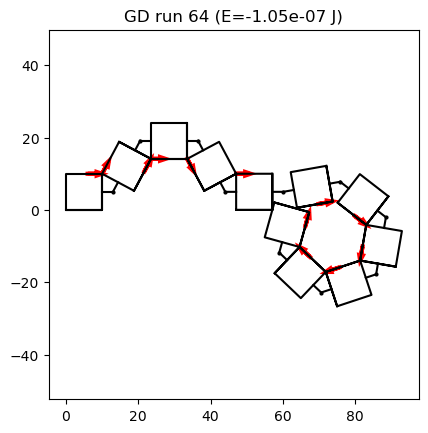

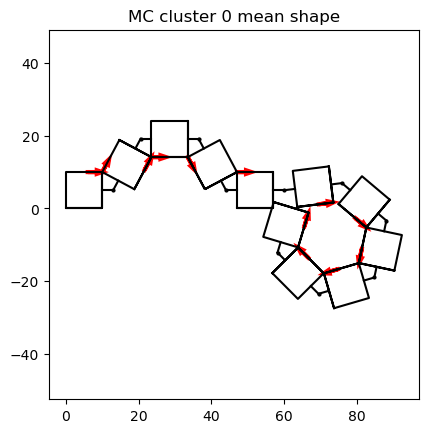

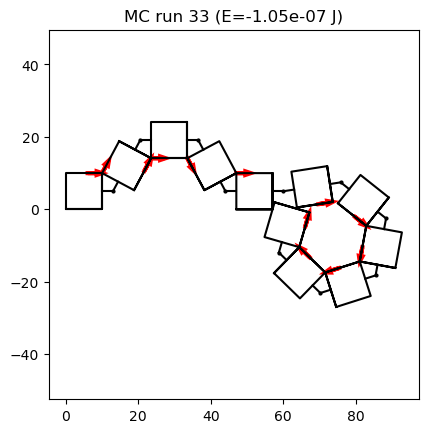

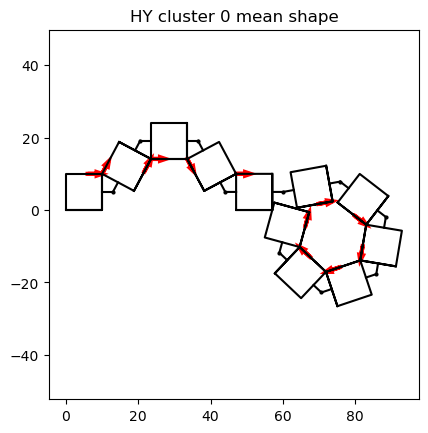

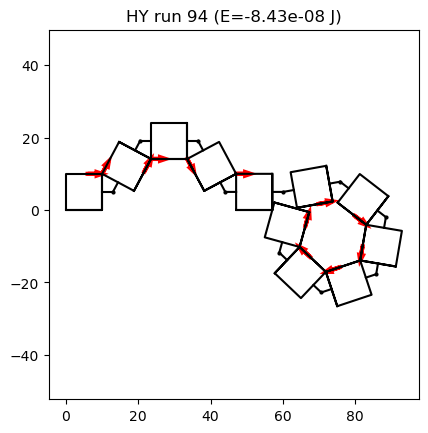

In [ ]:
#Note: this cell only really makes sense for no fabrication uncertainty runs
# Diagnose the low-energy (~-1e-7 J) population visible in the final-energy histograms that
# doesn't separate out as its own hinge-angle cluster. Hypothesis: it's not a distinct backbone
# shape, but an existing cluster's shape with one or two hinges tweaked enough to snap two magnetic
# poles into much closer contact - energy is a near-singular Ml/r pairwise sum (energy_math in
# visualization_functions.py), so a small, localized hinge change can swing energy far more than it
# moves the run's position in full hinge-angle (Euclidean) space, which is all cluster_populations
# clusters on.

target_energy = -1e-7  # J, the low-energy shoulder called out in the final-energy histograms
tol = 0.3e-7            # J, half-width of the band around target_energy

def diagnose_low_energy_population(final_hinges, final_es, cluster_labels, method_name, target_energy=target_energy, tol=tol):
    mask = np.abs(final_es - target_energy) < tol
    outlier_idx = np.where(mask)[0]

    print(f"\n=== {method_name}: {len(outlier_idx)} run(s) with final energy within {tol:.1e} J of {target_energy:.1e} J ===")
    if len(outlier_idx) == 0:
        return None

    outlier_clusters = cluster_labels[outlier_idx]
    print("Cluster assignment of these runs:", dict(zip(*np.unique(outlier_clusters, return_counts=True))))

    rows = []
    for idx in outlier_idx:
        k = cluster_labels[idx]
        # mean hinge vector of the rest of that cluster, excluding this run itself
        cluster_mask = (cluster_labels == k).copy()
        cluster_mask[idx] = False
        cluster_mean_hinges = final_hinges[cluster_mask].mean(axis=0)
        cluster_mean_energy = final_es[cluster_mask].mean()

        diff = np.abs(final_hinges[idx] - cluster_mean_hinges)
        top_hinges = np.argsort(diff)[::-1][:2]

        rows.append({
            "run": idx,
            "energy (J)": final_es[idx],
            "cluster": k,
            "cluster mean energy (J)": cluster_mean_energy,
            "biggest-deviation hinge(s)": list(top_hinges),
            "deviation (deg)": [round(diff[h], 2) for h in top_hinges],
        })

    df = pd.DataFrame(rows).sort_values("energy (J)").reset_index(drop=True)
    display(df)
    return df

diag_gd = diagnose_low_energy_population(final_hinges_gd, final_es_gd, cluster_labels_gd_pop, "GD")
diag_mc = diagnose_low_energy_population(final_hinges_mc, final_es_mc, cluster_labels_mc_pop, "MC")
diag_ws = diagnose_low_energy_population(final_hinges_ws, final_es_ws, cluster_labels_ws_pop, "WS")
diag_hy = diagnose_low_energy_population(final_hinges_hy, final_es_hy, cluster_labels_hy_pop, "HY")

# Visually compare, for each method, the lowest-energy outlier's actual shape against the mean
# shape of the cluster it got folded into - if it's a "snap" rather than a new fold, they should
# look almost identical except at the biggest-deviation hinge(s) reported above.
hinges = list(range(final_hinges_gd.shape[1]))

def plot_hinge_state(hinge_angles, title):
    hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)
    for j, hingechoice in enumerate(hinges):
        angle = hinge_angles[j] - hinge_vec[hingechoice]
        patch_arr, shape_arr, hinge_vec, hinge_loc = vis.rotate_once(
            patch_arr, shape_arr, linelist, hinge_vec, hingechoice, hinge_loc, angle, patch_num
        )
    vis.shapeplots(shape_arr, linelist, hinge_loc, blocking=False, title=title, show=True, bounds='', mag_vecs=patch_arr)

for method_name, final_hinges, final_es, cluster_labels, diag_df in [
    ("GD", final_hinges_gd, final_es_gd, cluster_labels_gd_pop, diag_gd),
    ("MC", final_hinges_mc, final_es_mc, cluster_labels_mc_pop, diag_mc),
    ("WS", final_hinges_ws, final_es_ws, cluster_labels_ws_pop, diag_ws),
    ("HY", final_hinges_hy, final_es_hy, cluster_labels_hy_pop, diag_hy),
]:
    if diag_df is None or len(diag_df) == 0:
        continue
    row = diag_df.iloc[0]  # lowest-energy example for this method
    idx, k = row["run"], row["cluster"]
    cluster_mask = (cluster_labels == k).copy()
    cluster_mask[idx] = False
    cluster_mean_hinges = final_hinges[cluster_mask].mean(axis=0)

    plot_hinge_state(cluster_mean_hinges, f"{method_name} cluster {k} mean shape")
    plot_hinge_state(final_hinges[idx], f"{method_name} run {idx} (E={row['energy (J)']:.2e} J)")

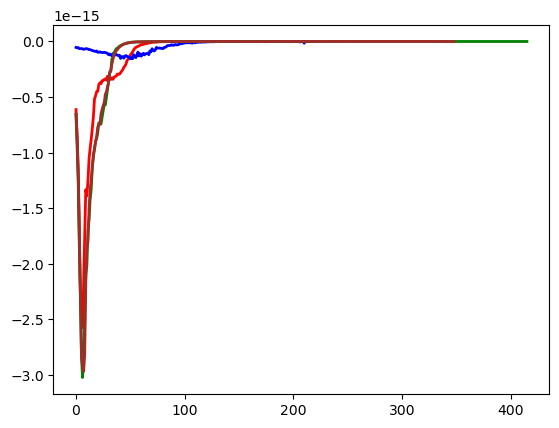

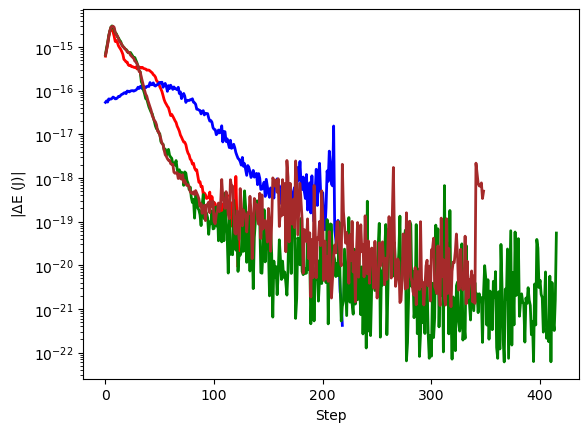

In [28]:
# delta energy vs. time

# for i in range(len(energies_gd)):
#     plt.plot(np.diff(energies_gd[i]),c='pink',alpha=0.1)

# for i in range(len(energies_mc)):
#     plt.plot(np.diff(energies_mc[i]),c='lightblue', alpha=0.1)

# for i in range(len(energies_ws)):
#     plt.plot(np.diff(energies_ws[i]),c='lightgreen', alpha = 0.1)

plt.plot(averageDeltaEnergies(energies_gd, mode='median'),c='r',lw=2)
plt.plot(averageDeltaEnergies(energies_mc, mode='median'),c='b',lw=2)
plt.plot(averageDeltaEnergies(energies_ws, mode='median'),c='g',lw=2)
plt.plot(averageDeltaEnergies(energies_hy, mode='median'),c='brown',lw=2)
plt.show()

plt.semilogy(abs(averageDeltaEnergies(energies_gd, mode='median')),c='r',lw=2)
plt.semilogy(abs(averageDeltaEnergies(energies_mc, mode='median')),c='b',lw=2)
plt.semilogy(abs(averageDeltaEnergies(energies_ws, mode='median')),c='g',lw=2)
plt.semilogy(abs(averageDeltaEnergies(energies_hy, mode='median')),c='brown',lw=2)

# plt.ylim(-0.1E-10,0)
# plt.xlim(0,100)

plt.xlabel("Step")
plt.ylabel("|$\Delta$E (J)|")
plt.show()



### Clustering

*** GD ***


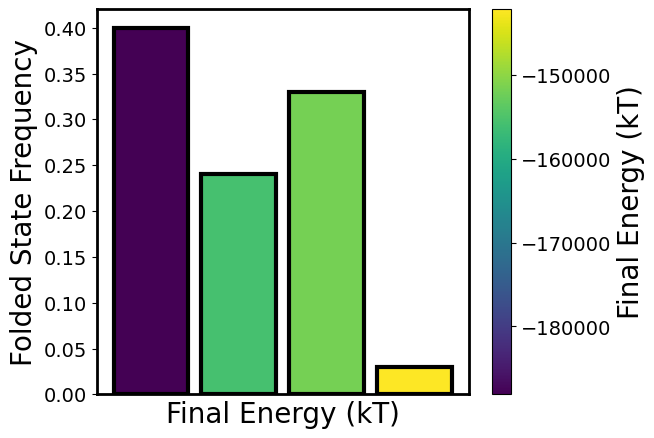

*** MC ***


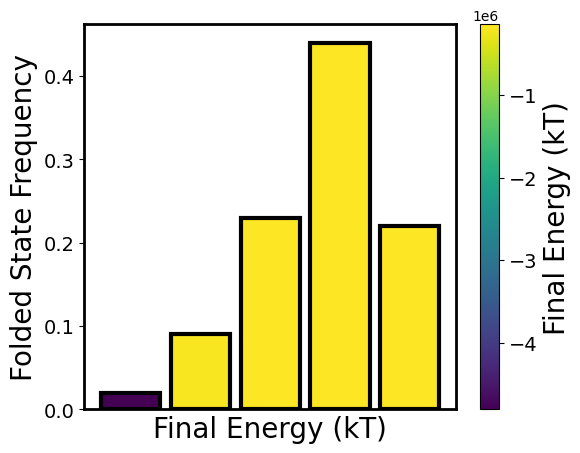

*** WS ***


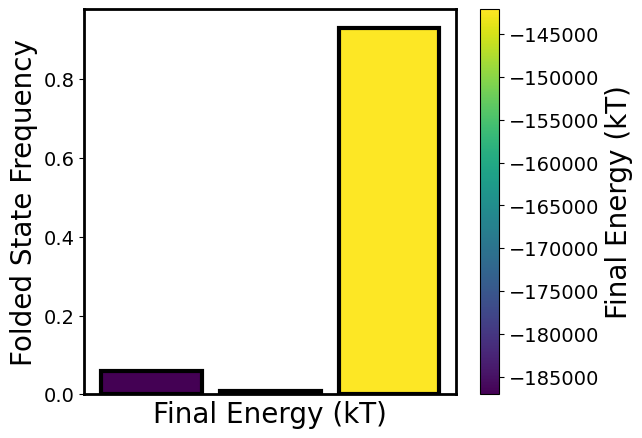

*** HY ***


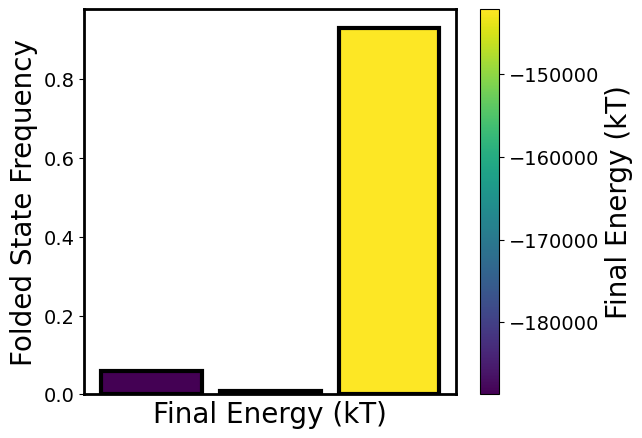

In [31]:
cluster_max = 6
states = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
print('*** GD ***')
clusternumber_gd = vis.cluster_num(final_hinges_gd,cluster_max,states, Plot = False)
clustercenters_gd, cluster_labels_gd, clusternumber_gd = vis.min_cluster_centers(final_hinges_gd, clusternumber_gd, final_es_gd)
clusternumbers_gd, cluster_count_gd, cluster_prob_gd, cluster_energies_gd, ordered_centers_gd, all_stds_gd = vis.cluster_stats(final_hinges_gd, clusternumber_gd, clustercenters_gd, cluster_labels_gd,
                                                                                                    final_es_gd, plot=True)
print('*** MC ***')
clusternumber_mc = vis.cluster_num(final_hinges_mc,cluster_max,states, Plot = False)
clustercenters_mc, cluster_labels_mc, clusternumber_mc = vis.min_cluster_centers(final_hinges_mc, clusternumber_mc, final_es_mc)
clusternumbers_mc, cluster_count_mc, cluster_prob_mc, cluster_energies_mc, ordered_centers_mc, all_stds_mc = vis.cluster_stats(final_hinges_mc, clusternumber_mc, clustercenters_mc, cluster_labels_mc,
                                                                                                    final_es_mc, plot=True)

print('*** WS ***')
clusternumber_ws = vis.cluster_num(final_hinges_ws,cluster_max,states, Plot = False)
clustercenters_ws, cluster_labels_ws, clusternumber_ws = vis.min_cluster_centers(final_hinges_ws, clusternumber_ws, final_es_ws)
clusternumbers_ws, cluster_count_ws, cluster_prob_ws, cluster_energies_ws, ordered_centers_ws, all_stds_ws = vis.cluster_stats(final_hinges_ws, clusternumber_ws, clustercenters_ws, cluster_labels_ws,
                                                                                                    final_es_ws, plot=True)

print('*** HY ***')
clusternumber_hy = vis.cluster_num(final_hinges_hy,cluster_max,states, Plot = False)
clustercenters_hy, cluster_labels_hy, clusternumber_hy = vis.min_cluster_centers(final_hinges_hy, clusternumber_hy, final_es_hy)
clusternumbers_hy, cluster_count_hy, cluster_prob_hy, cluster_energies_hy, ordered_centers_hy, all_stds_hy = vis.cluster_stats(final_hinges_hy, clusternumber_hy, clustercenters_hy, cluster_labels_hy,
                                                                                                    final_es_hy, plot=True)

*** GD ***


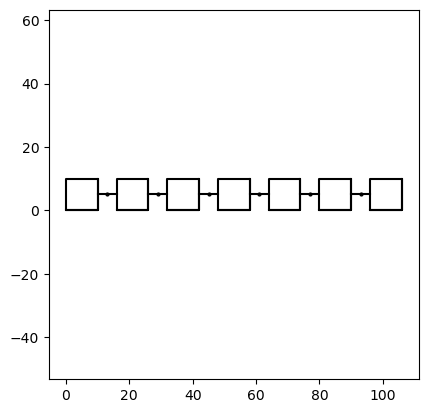

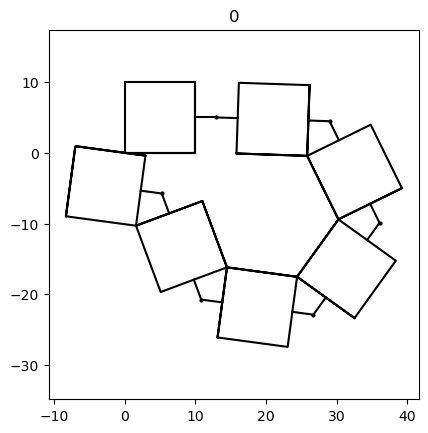

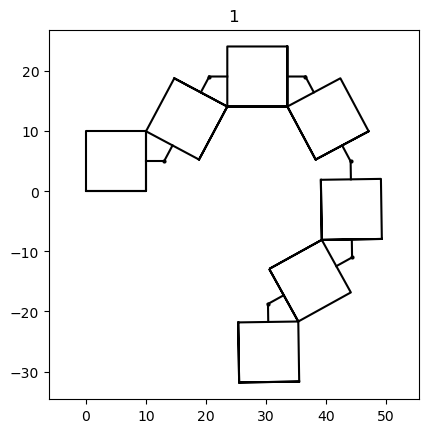

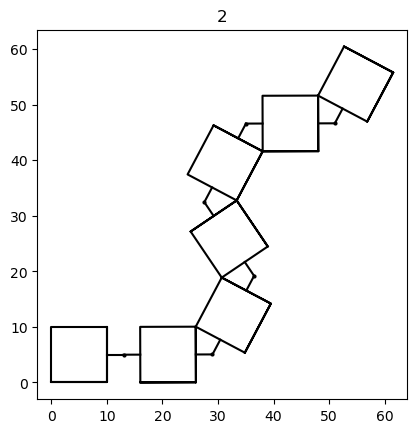

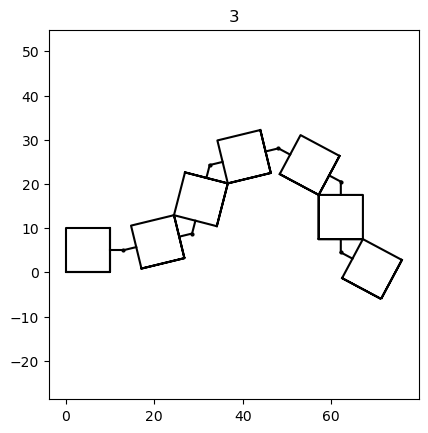

*** MC ***


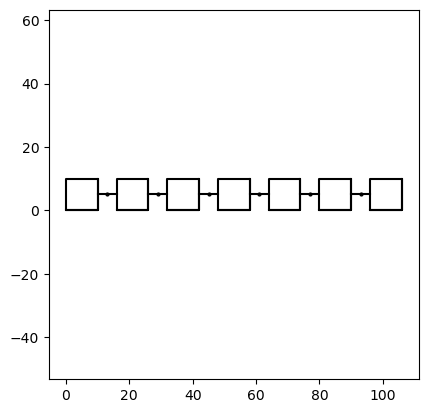

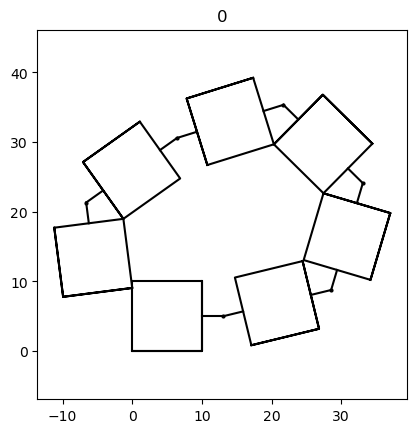

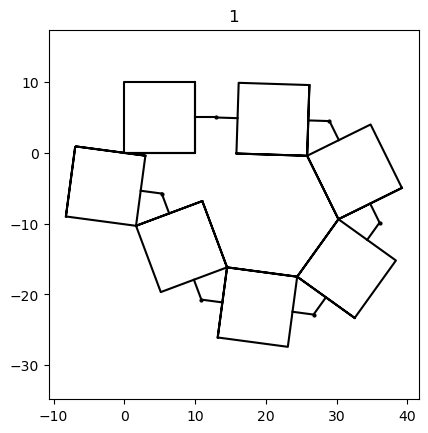

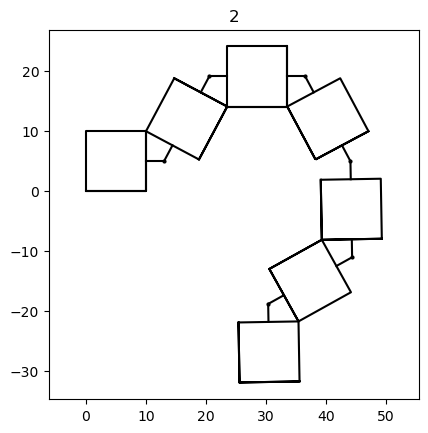

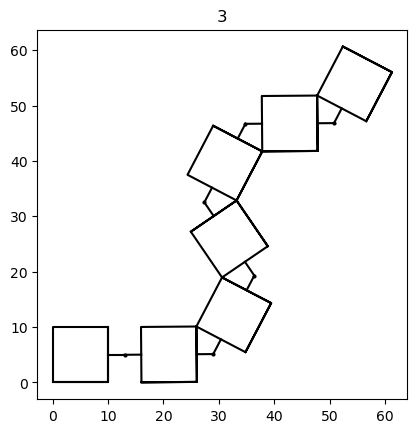

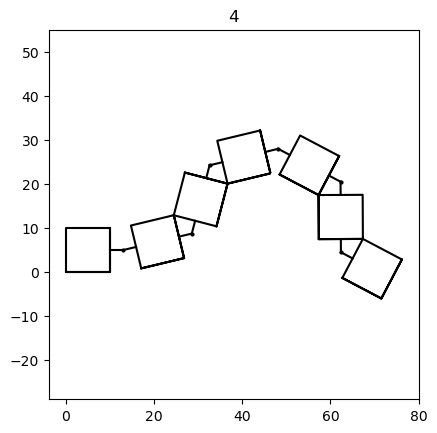

*** WS ***


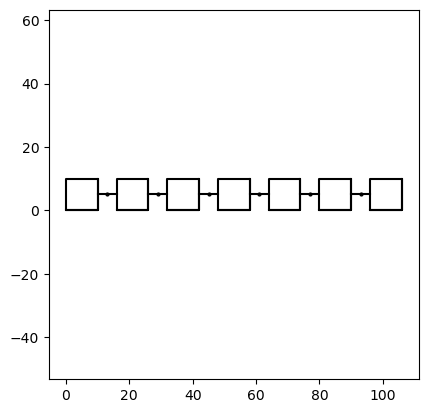

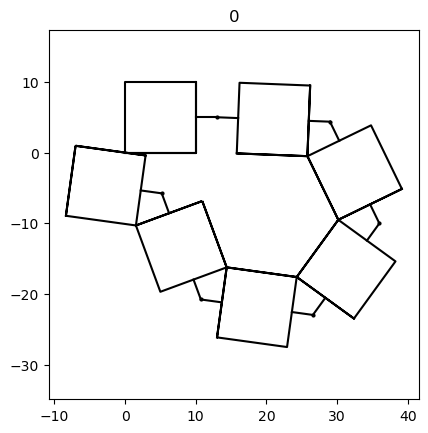

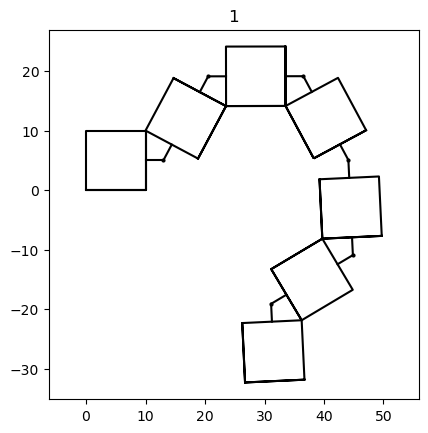

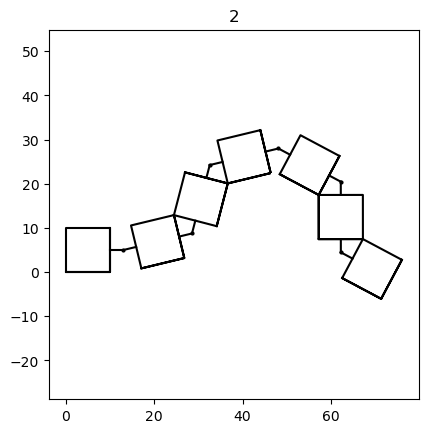

*** HY ***


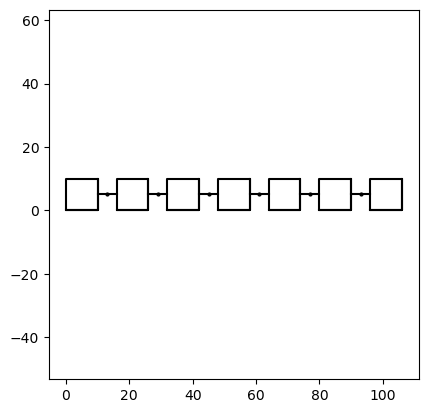

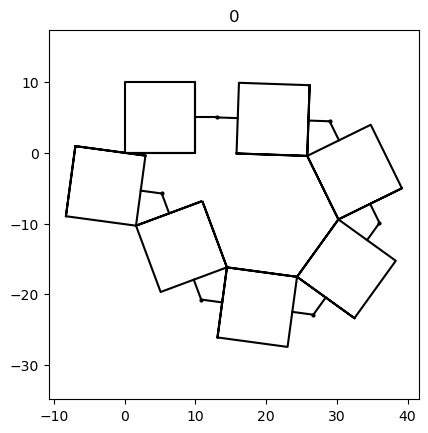

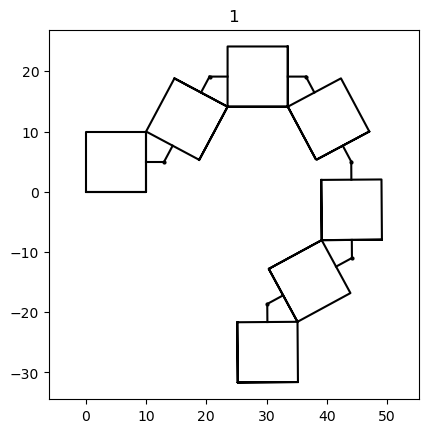

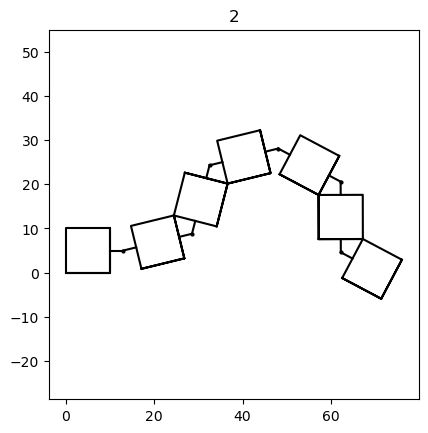

In [32]:
# show the conformations of the clusters from above
hinges=np.linspace(0,len(shapes)-2,len(shapes)-1).astype(int)
print('*** GD ***')
vis.show_probable_structures(hinges, shapes, ordered_centers_gd)
print('*** MC ***')
vis.show_probable_structures(hinges, shapes, ordered_centers_mc)
print('*** WS ***')
vis.show_probable_structures(hinges, shapes, ordered_centers_ws)
print('*** HY ***')
vis.show_probable_structures(hinges, shapes, ordered_centers_hy)

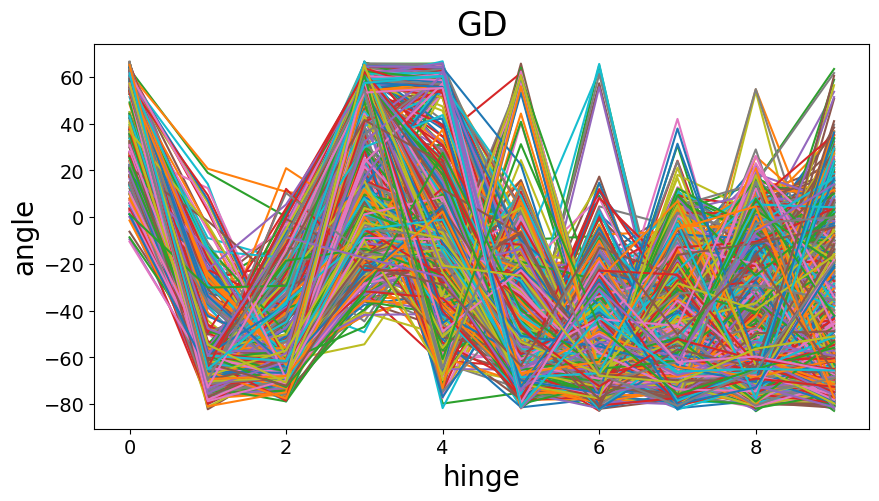

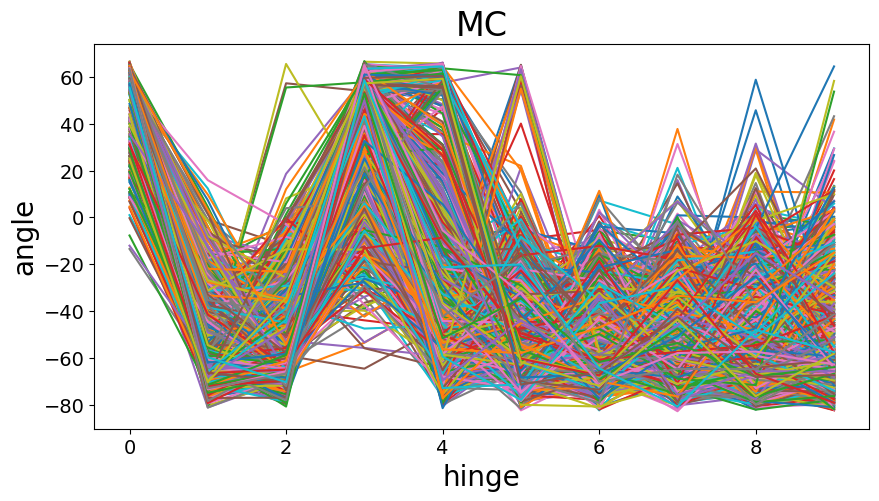

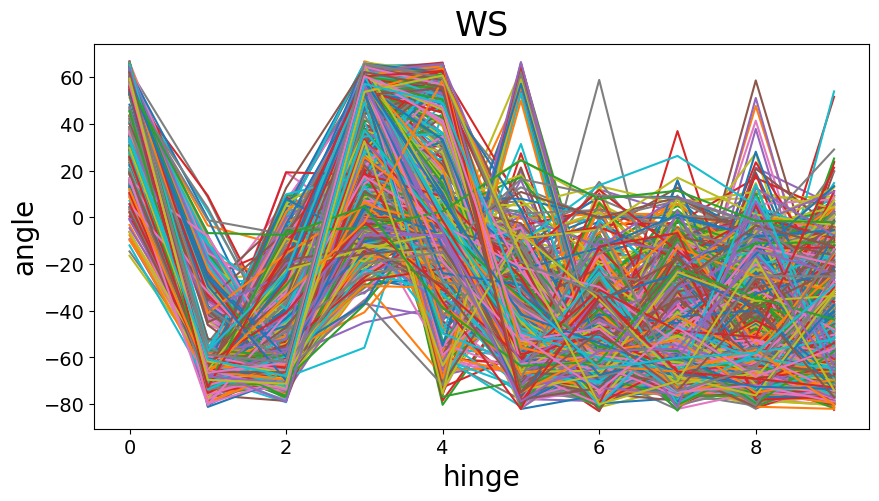

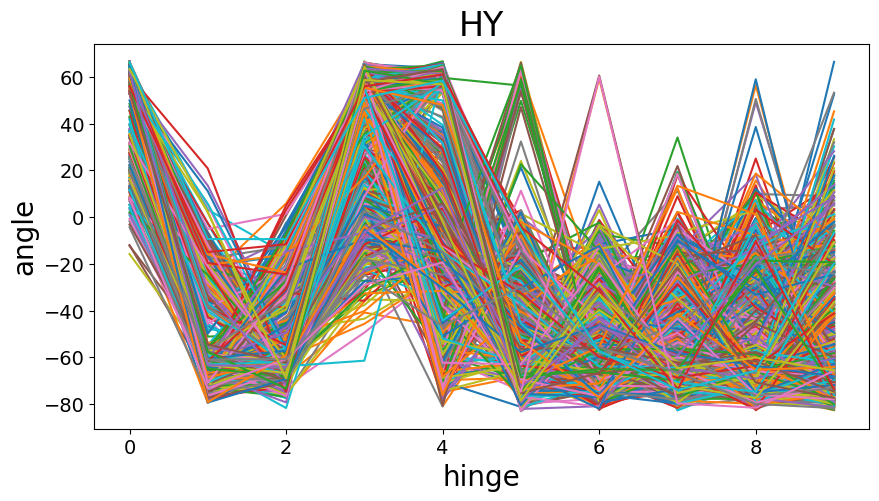

In [9]:
# plot hinge angles vs hinge number to confirm population distributions

plt.plot(final_hinges_gd.T - 180)
plt.title("GD", fontsize=24)
plt.xlabel("hinge", fontsize=20)
plt.ylabel("angle", fontsize=20)
plt.gcf().set_size_inches(10, 5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.plot(final_hinges_mc.T - 180)
plt.title("MC", fontsize=24)
plt.xlabel("hinge", fontsize=20)
plt.ylabel("angle", fontsize=20)
plt.gcf().set_size_inches(10, 5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.plot(final_hinges_ws.T - 180)
plt.title("WS", fontsize=24)
plt.xlabel("hinge", fontsize=20)
plt.ylabel("angle", fontsize=20)
plt.gcf().set_size_inches(10, 5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

plt.plot(final_hinges_hy.T - 180)
plt.title("HY", fontsize=24)
plt.xlabel("hinge", fontsize=20)
plt.ylabel("angle", fontsize=20)
plt.gcf().set_size_inches(10, 5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

### Quantitative method comparison: convergence speed, global-minimum hit rate, significance

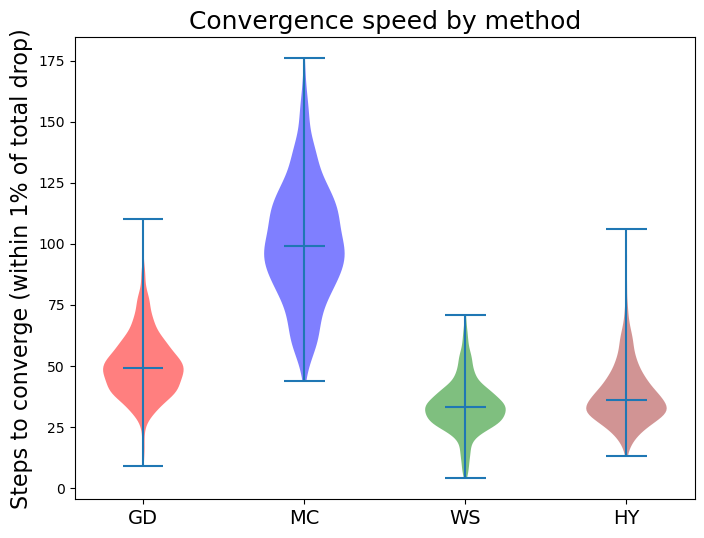

GD: median=49, mean=50.2, 90th pct=68, max=110
MC: median=99, mean=100.4, 90th pct=132, max=176
WS: median=33, mean=33.6, 90th pct=48, max=71
HY: median=36, mean=38.4, 90th pct=55, max=106


In [6]:
# Steps-to-convergence: for each run, the earliest step after which the energy stays within
# `frac` of the total drop (E0 - Efinal) for the rest of the run. Turns the "active trials"
# decay curves in the population-coloring cell above into one comparable cost number per run,
# instead of eyeballing where the curves flatten.

def steps_to_converge(energies, frac=0.01):
    steps = np.empty(len(energies), dtype=int)
    for i, traj in enumerate(energies):
        traj = np.asarray(traj)
        total_drop = abs(traj[0] - traj[-1])
        tol = frac * total_drop if total_drop > 0 else np.inf
        not_within = np.where(np.abs(traj - traj[-1]) > tol)[0]
        steps[i] = (not_within[-1] + 1) if len(not_within) else 0
    return steps

conv_gd = steps_to_converge(energies_gd)
conv_mc = steps_to_converge(energies_mc)
conv_ws = steps_to_converge(energies_ws)
conv_hy = steps_to_converge(energies_hy)

labels = ["GD", "MC", "WS", "HY"]
conv_data = [conv_gd, conv_mc, conv_ws, conv_hy]
colors = ['r', 'b', 'g', 'brown']

fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot(conv_data, showmedians=True)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel("Steps to converge (within 1% of total drop)", fontsize=16)
ax.set_title("Convergence speed by method", fontsize=18)
plt.show()

for name, conv in zip(labels, conv_data):
    print(f"{name}: median={np.median(conv):.0f}, mean={np.mean(conv):.1f}, "
          f"90th pct={np.percentile(conv, 90):.0f}, max={conv.max()}")

In [33]:
# Global-minimum hit rate: cluster_labels_*_pop (from the population-coloring cell above) are
# ranked so cluster 0 = lowest mean final energy = the global-minimum basin. This turns
# cluster_prob_* into one number per method: how often does it actually find the best known state,
# vs. getting stuck in a higher-energy local minimum.

methods = ["GD", "MC", "WS", "HY"]
cluster_label_sets = [cluster_labels_gd_pop, cluster_labels_mc_pop, cluster_labels_ws_pop, cluster_labels_hy_pop]
hit_rates = [np.mean(labels == 0) for labels in cluster_label_sets]
hit_counts = [int(np.sum(labels == 0)) for labels in cluster_label_sets]
totals = [len(labels) for labels in cluster_label_sets]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(methods, hit_rates, color=['r', 'b', 'g', 'brown'], alpha=0.7)
for bar, n, N in zip(bars, hit_counts, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{n}/{N}",
            ha='center', fontsize=12)
ax.set_ylabel("Fraction of runs in global-minimum cluster", fontsize=16)
ax.set_title("Global-minimum hit rate by method", fontsize=18)
ax.set_ylim(0, 1.1)
plt.show()

NameError: name 'cluster_labels_gd_pop' is not defined

In [41]:
# Pairwise significance tests on final-energy distributions: the histograms above look different,
# but with ~1000 runs per method it's worth confirming that's not noise. KS tests whether the
# full distributions differ; Mann-Whitney tests whether one method's energies are stochastically
# lower/higher than another's.

import itertools
from scipy import stats

methods_es = {"GD": final_es_gd, "MC": final_es_mc, "WS": final_es_ws, "HY": final_es_hy}
rows = []
for a, b in itertools.combinations(methods_es, 2):
    ks_stat, ks_p = stats.ks_2samp(methods_es[a], methods_es[b])
    mw_stat, mw_p = stats.mannwhitneyu(methods_es[a], methods_es[b], alternative='two-sided')
    rows.append({
        "comparison": f"{a} vs {b}",
        "median E_a (J)": np.median(methods_es[a]),
        "median E_b (J)": np.median(methods_es[b]),
        "KS stat": ks_stat,
        "KS p": ks_p,
        "MW p": mw_p,
    })

display(pd.DataFrame(rows))

,comparison,median E_a (J),median E_b (J),KS stat,KS p,MW p
0,GD vs MC,-4.119374e-08,-1.816771e-08,0.291,1.014560e-37,5.644383e-50
1,GD vs WS,-4.119374e-08,-1.208709e-08,0.421,8.247170e-80,1.688385e-95
2,GD vs HY,-4.119374e-08,-3.136378e-08,0.104,3.958740e-05,3.752874e-06
3,MC vs WS,-1.816771e-08,-1.208709e-08,0.159,1.907452e-11,2.506924e-13
4,MC vs HY,-1.816771e-08,-3.136378e-08,0.236,7.858036e-25,2.265486e-30
5,WS vs HY,-1.208709e-08,-3.136378e-08,0.373,2.661666e-62,9.502334e-74


### Additional testing for the ending of GD vs MC and WS (lead to HY development)

In [ ]:
# run MC and WS down to some final populations
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
patch_arr_mc, shape_arr_mc, hinge_vec_mc, hinge_loc_mc, current_energy_mc, energy_mc = sim.simulate_monteCarlo(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
patch_arr_ws, shape_arr_ws, hinge_vec_ws, hinge_loc_ws, current_energy_ws, energy_ws = sim.simulate_weightedSync(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
        

MC:  -4.838303919606904e-09
WS:  -3.937784518732032e-08


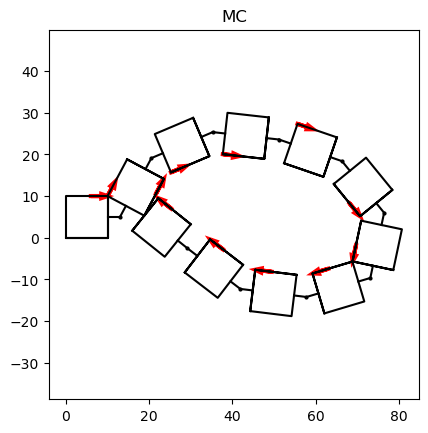

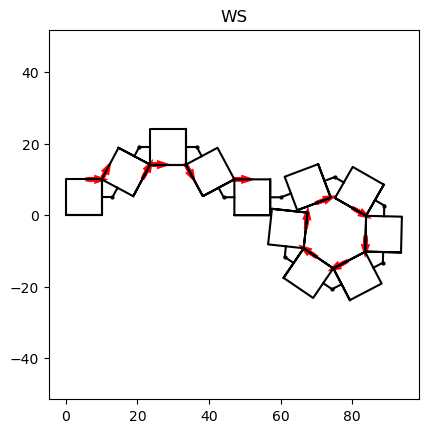

In [ ]:
# print out the energies and plot the shapes
print("MC: ", current_energy_mc)
print("WS: ", current_energy_ws)

vis.shapeplots(shape_arr_mc, linelist, hinge_loc_mc, blocking = False, title = 'MC', show = True, bounds = '', mag_vecs = patch_arr_mc)
vis.shapeplots(shape_arr_ws, linelist, hinge_loc_ws, blocking = False, title = 'WS', show = True, bounds = '', mag_vecs = patch_arr_ws)

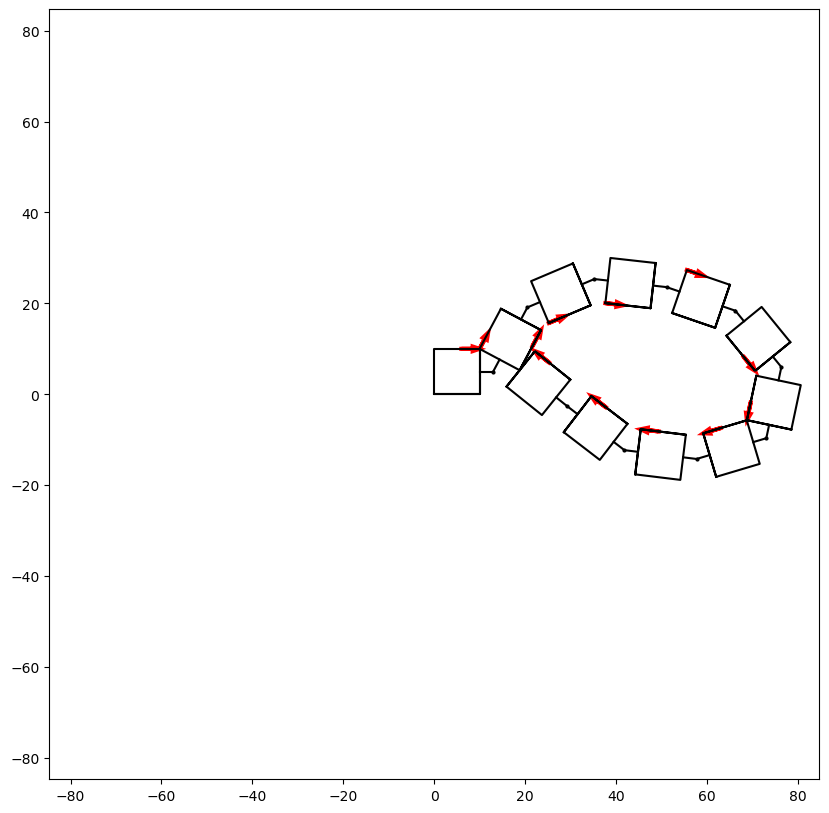

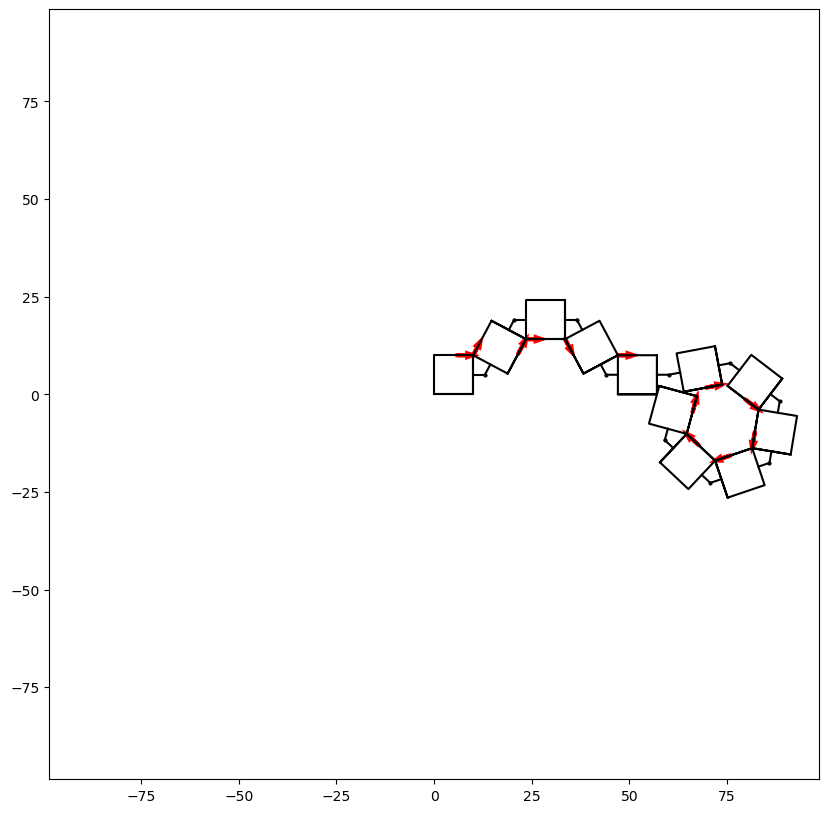

In [ ]:
patch_arr_gdmc, shape_arr_gdmc, hinge_vec_gdmc, hinge_loc_gdmc, current_energy_gdmc, energy_gdmc = sim.simulate_greedyDescent(patch_arr_mc,shape_arr_mc,linelist,hinge_vec_mc, hinge_loc_mc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=1, ani_folder='tests')
patch_arr_gdws, shape_arr_gdws, hinge_vec_gdws, hinge_loc_gdws, current_energy_gdws, energy_gdws = sim.simulate_greedyDescent(patch_arr_ws,shape_arr_ws,linelist,hinge_vec_ws, hinge_loc_ws, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=2, ani_folder='tests')

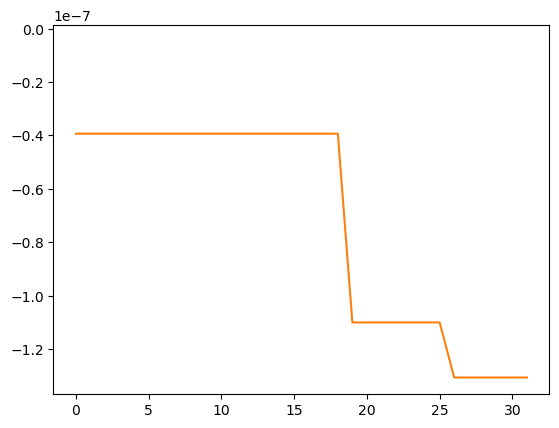

In [ ]:
plt.plot(energy_gdmc)
plt.plot(energy_gdws)

/Users/dylanmccuskey/PythonProjects/MagneticActuators/Git/Magnetic-actuator-simulation/sim_methods.py:187: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10,10))


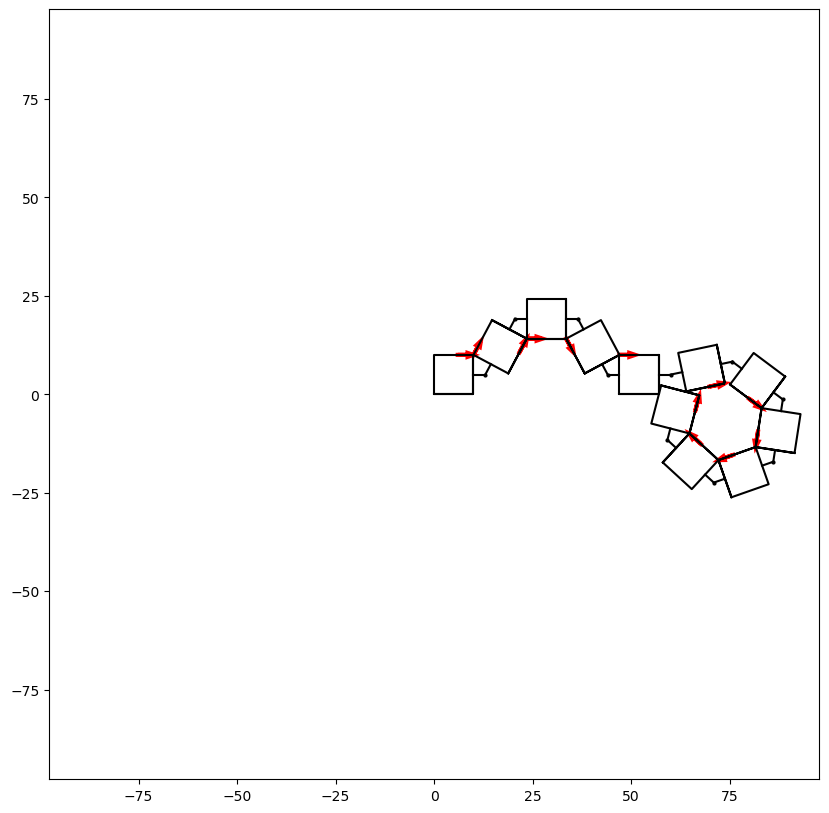

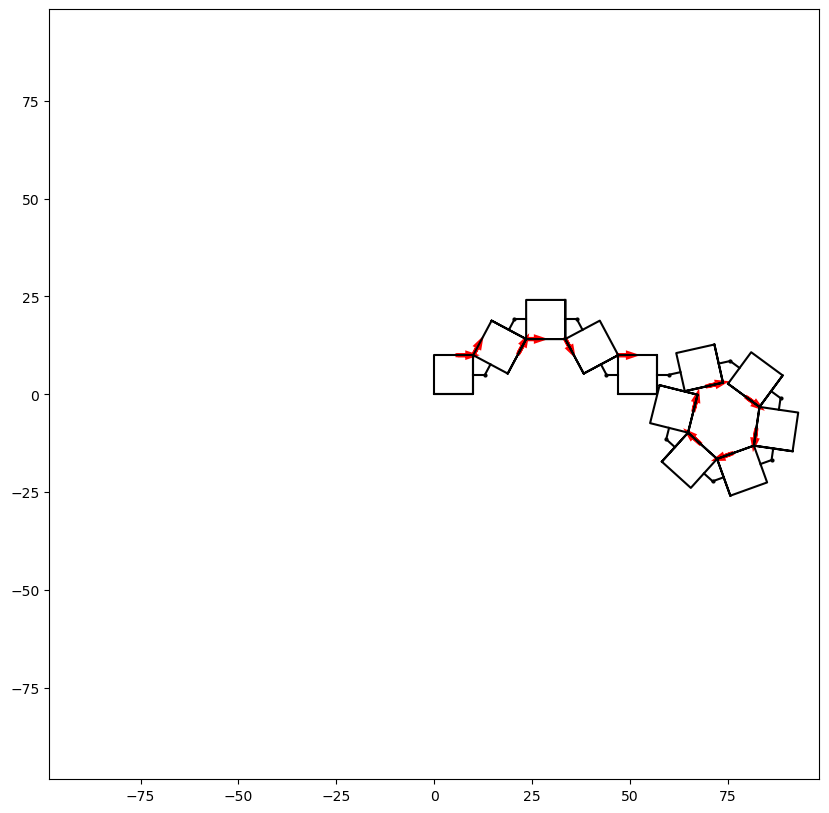

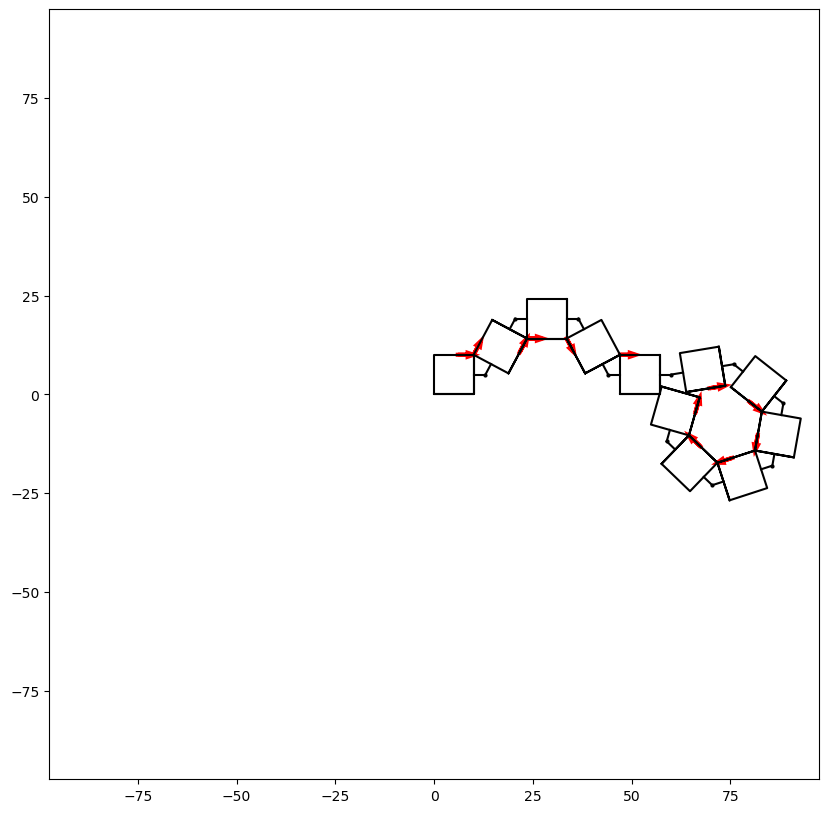

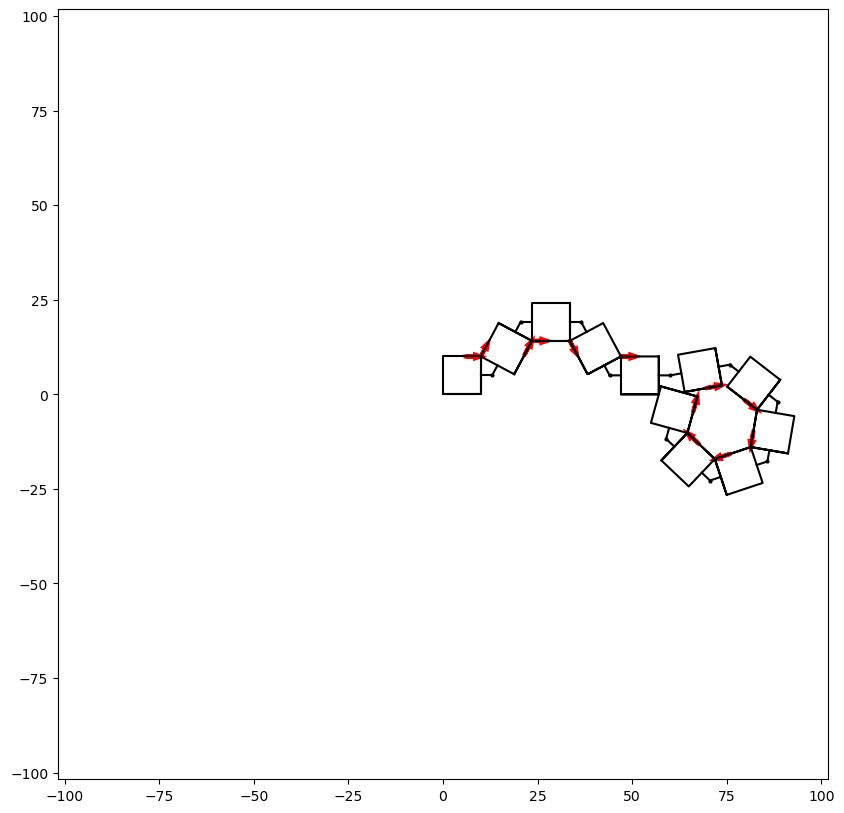

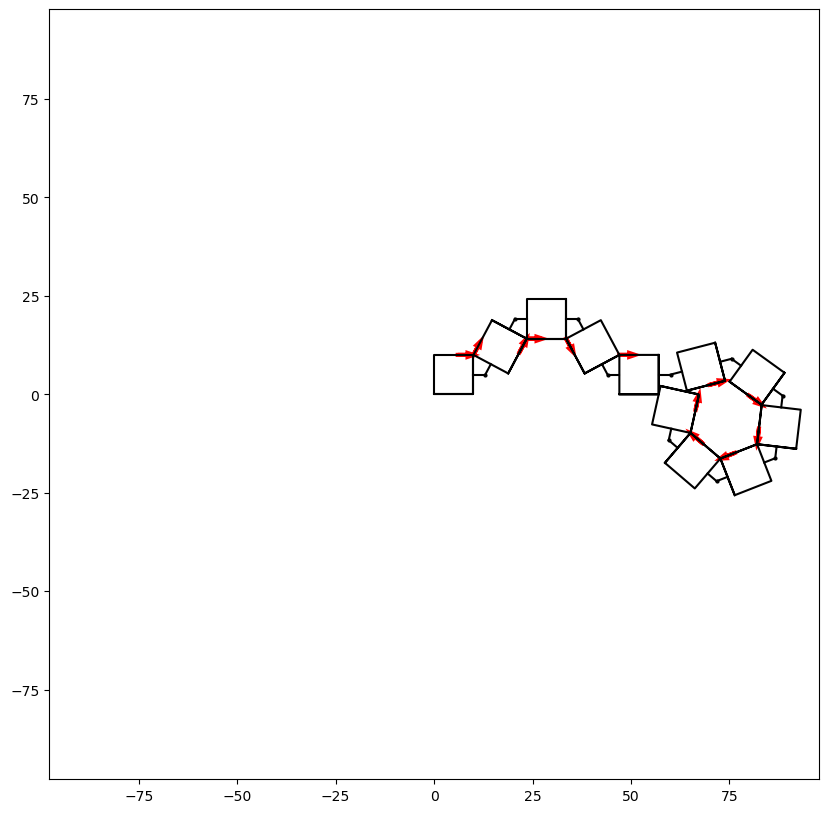

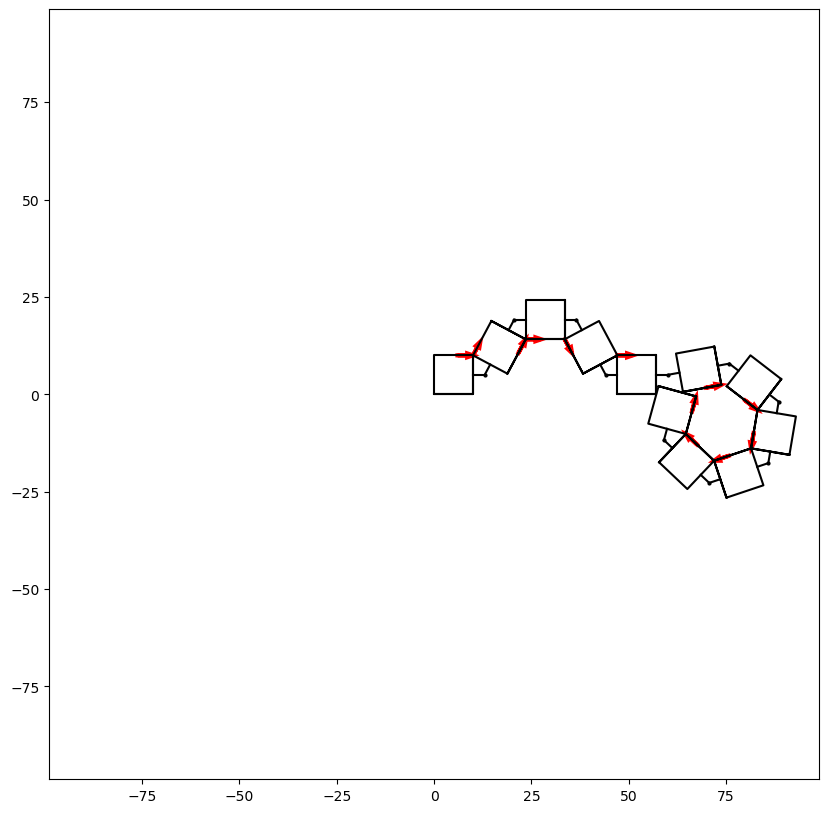

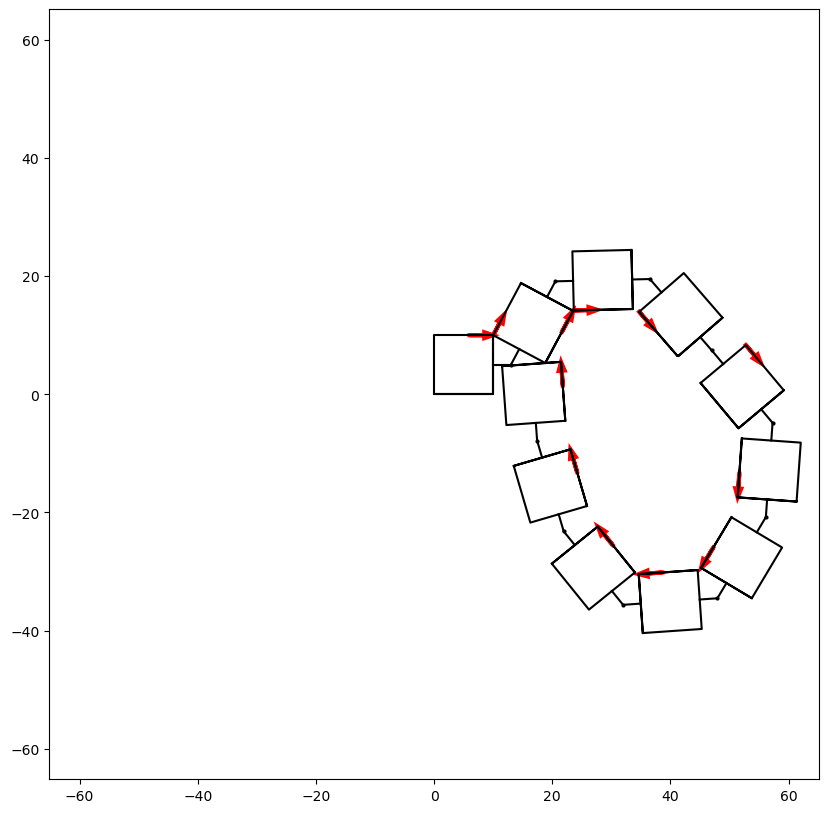

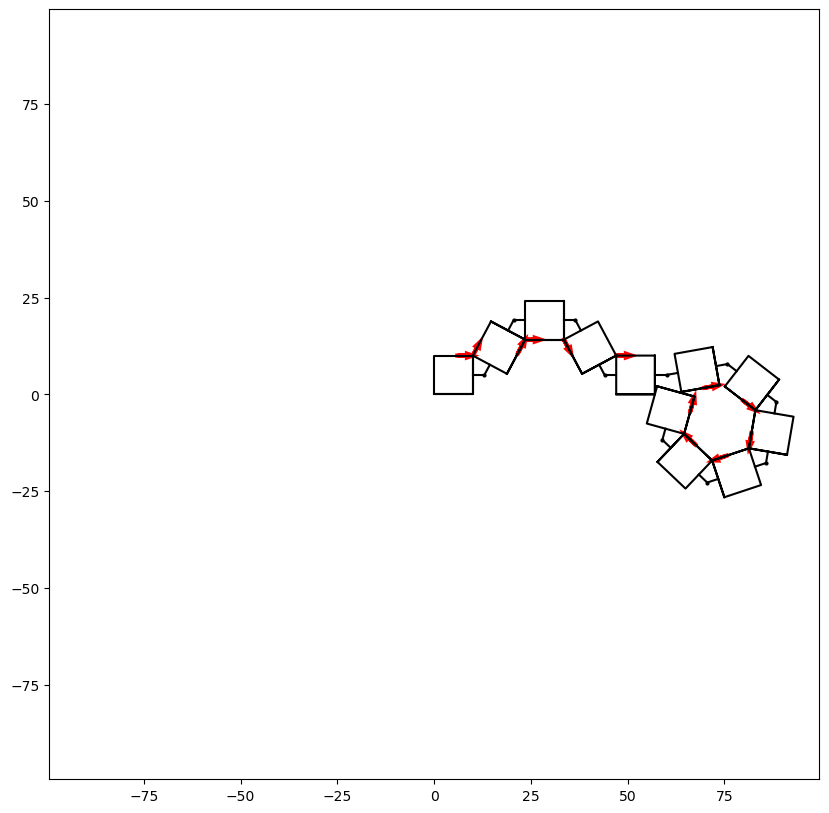

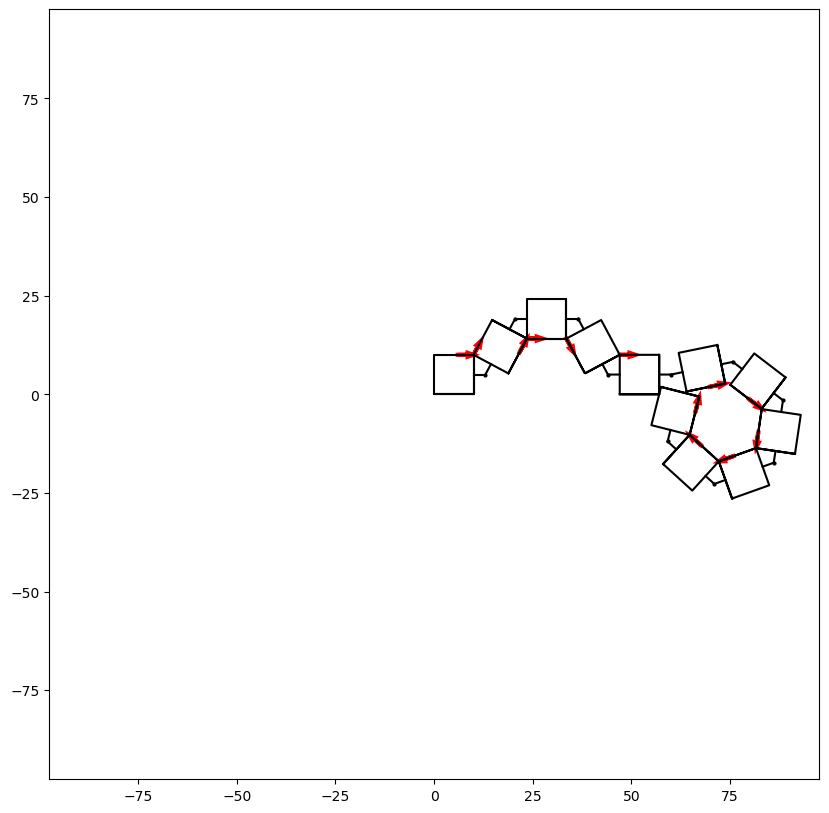

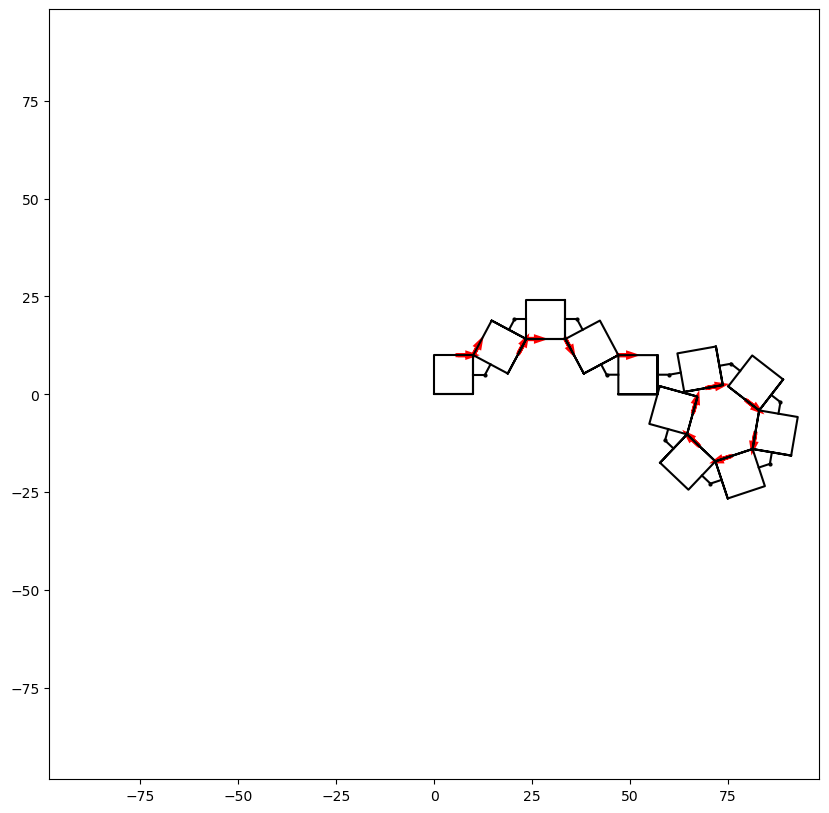

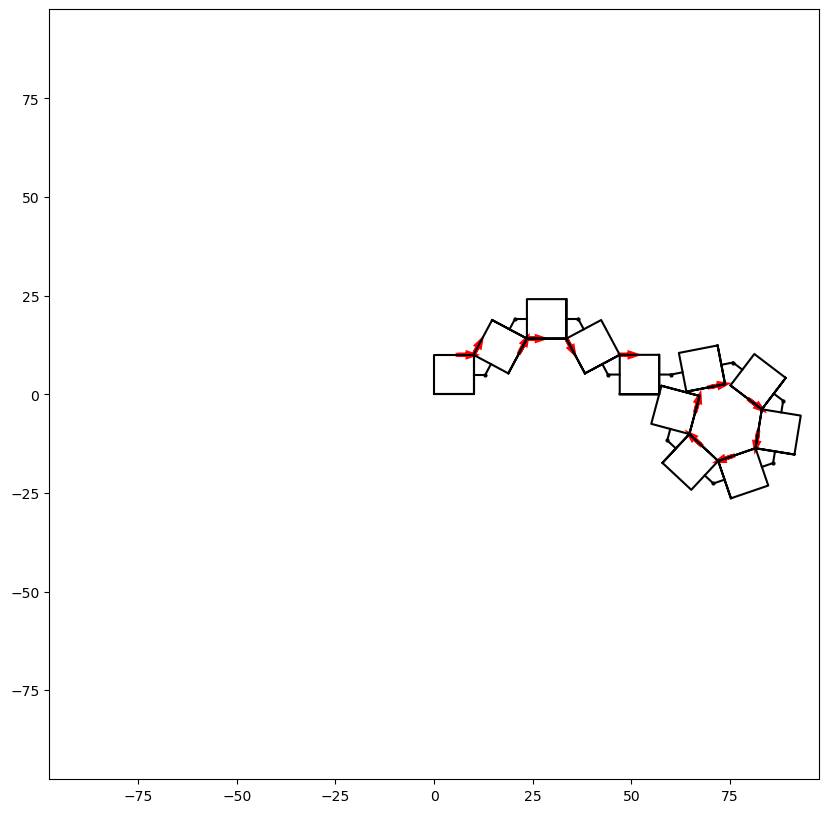

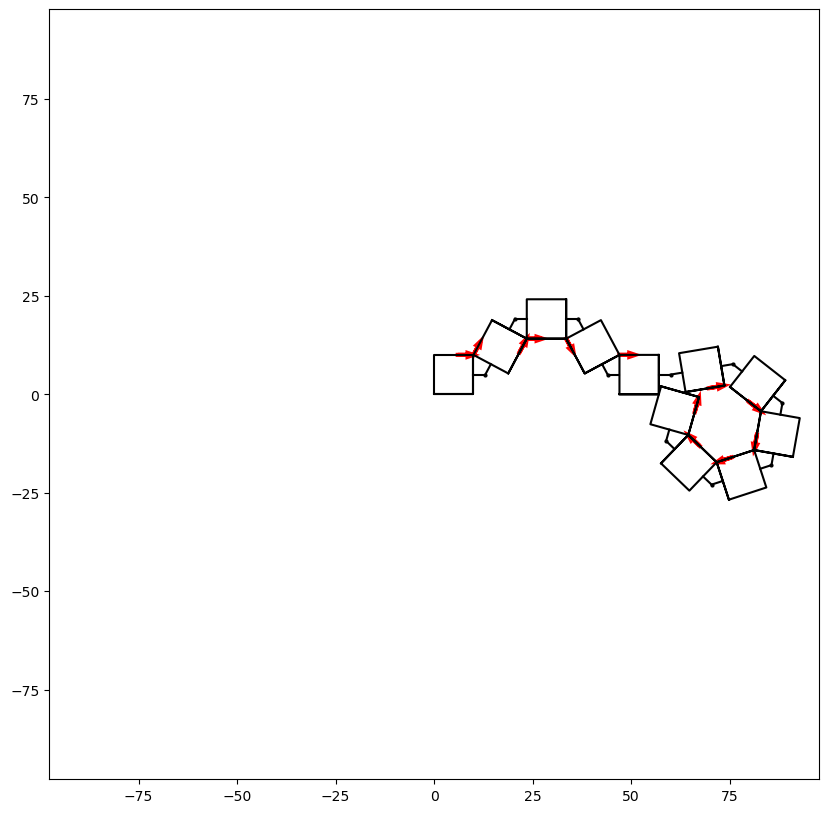

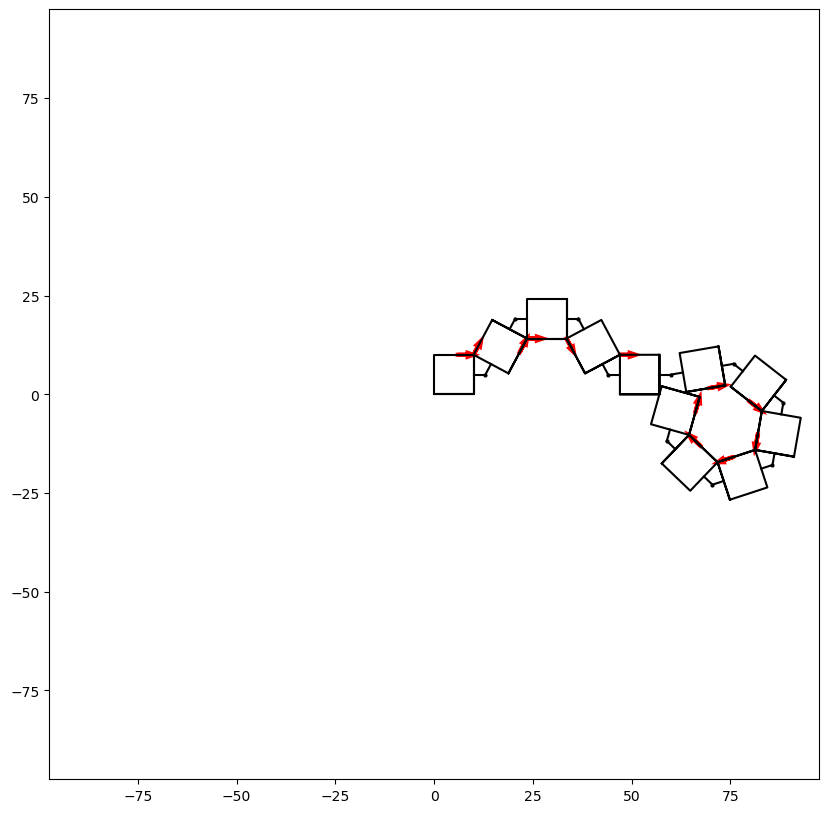

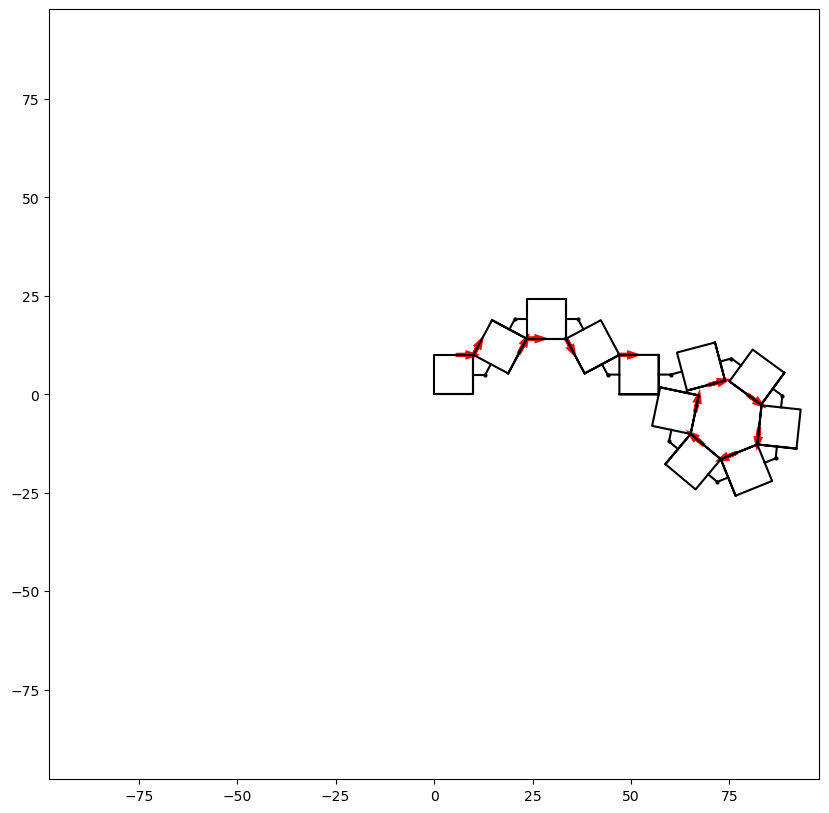

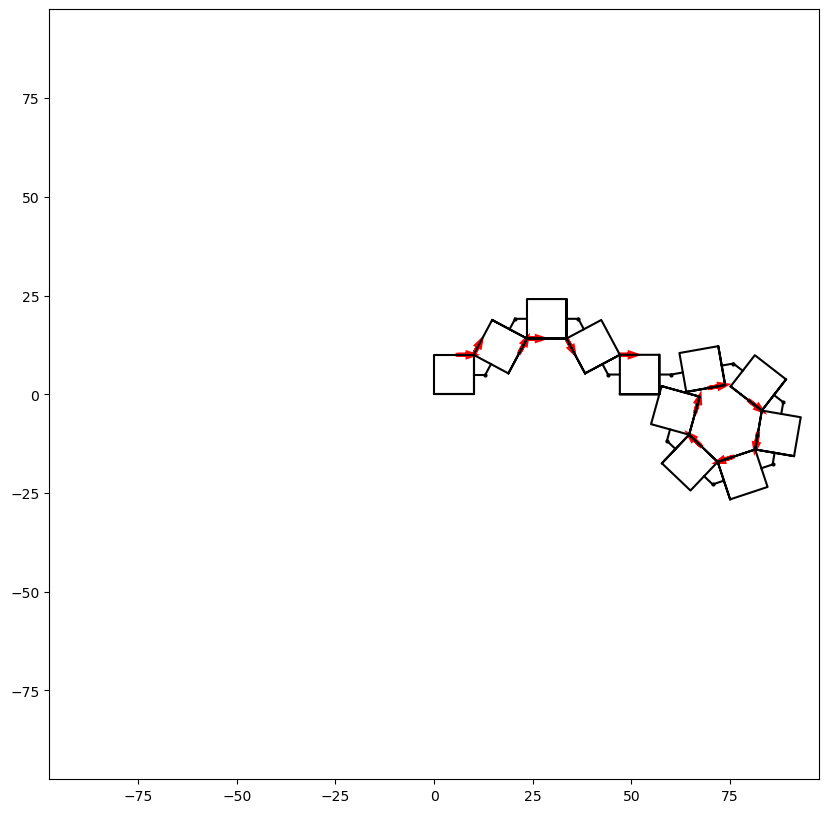

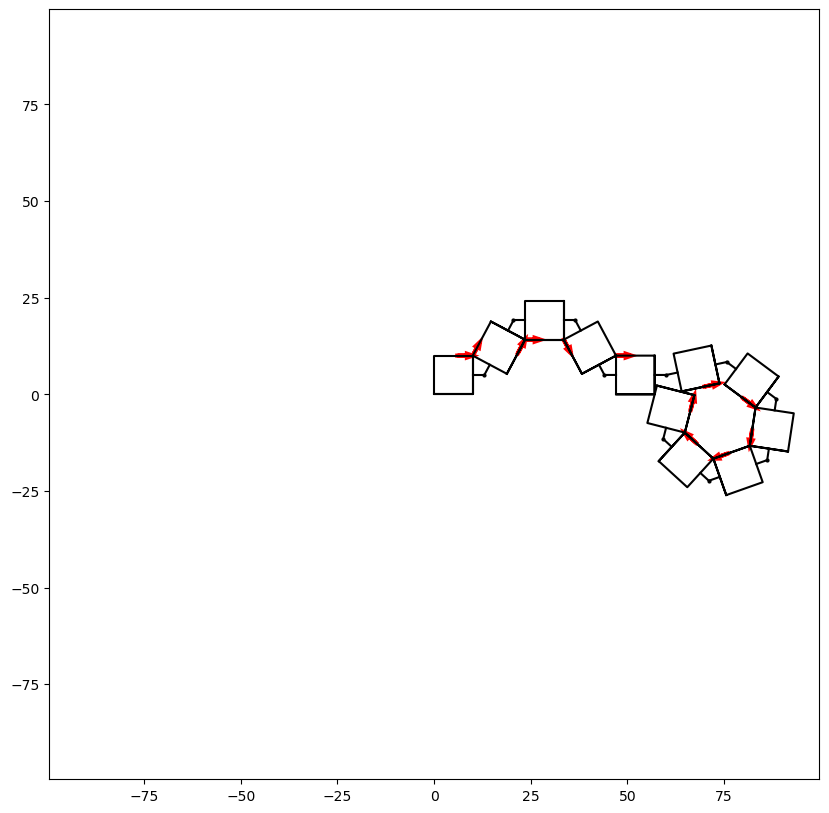

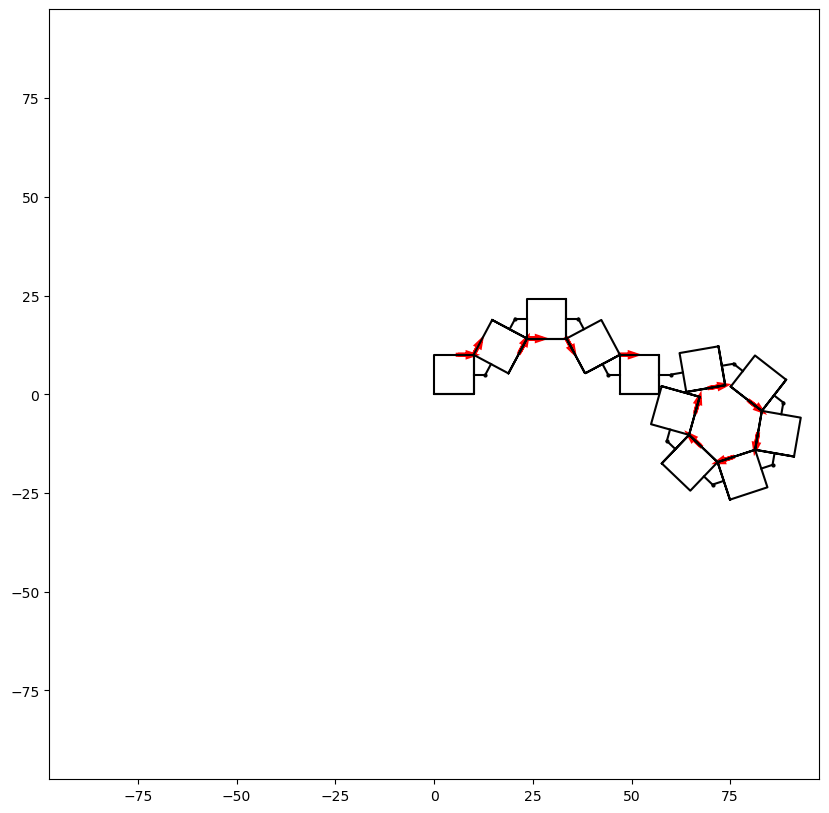

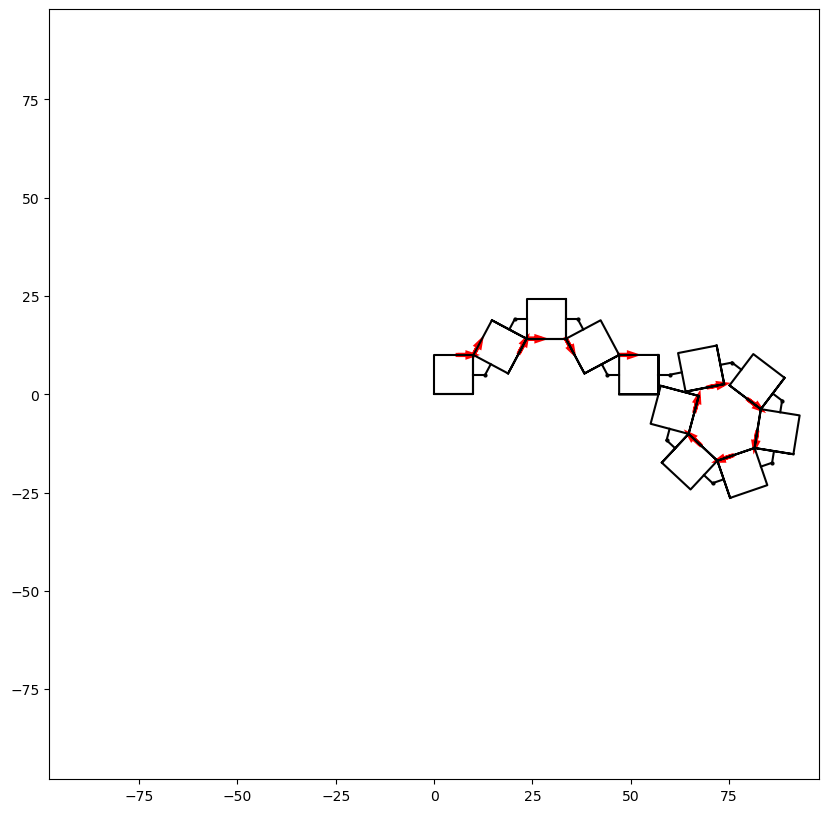

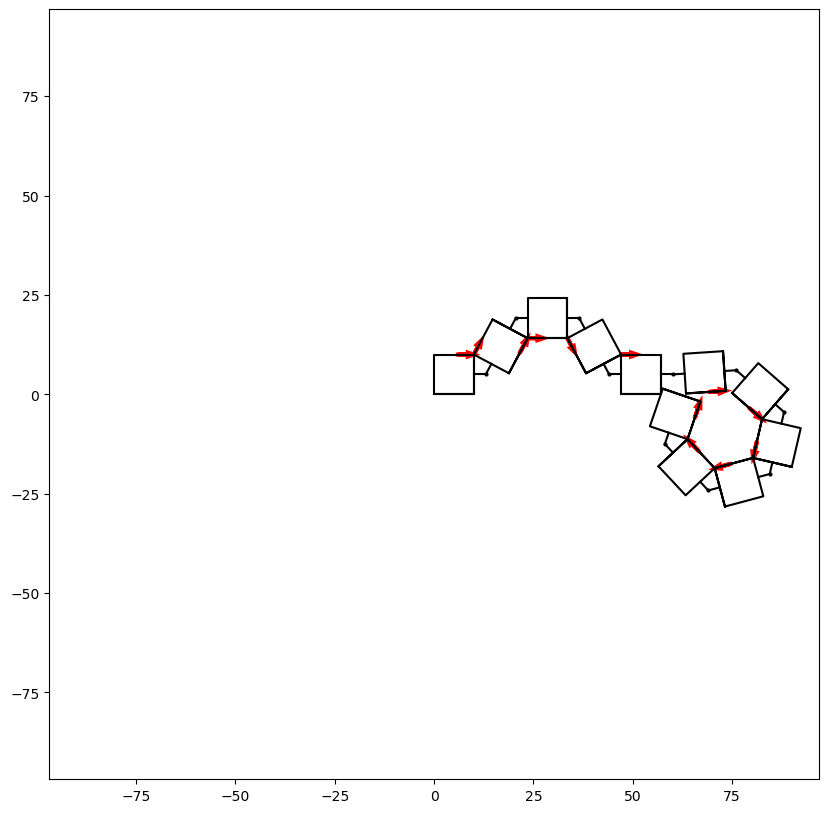

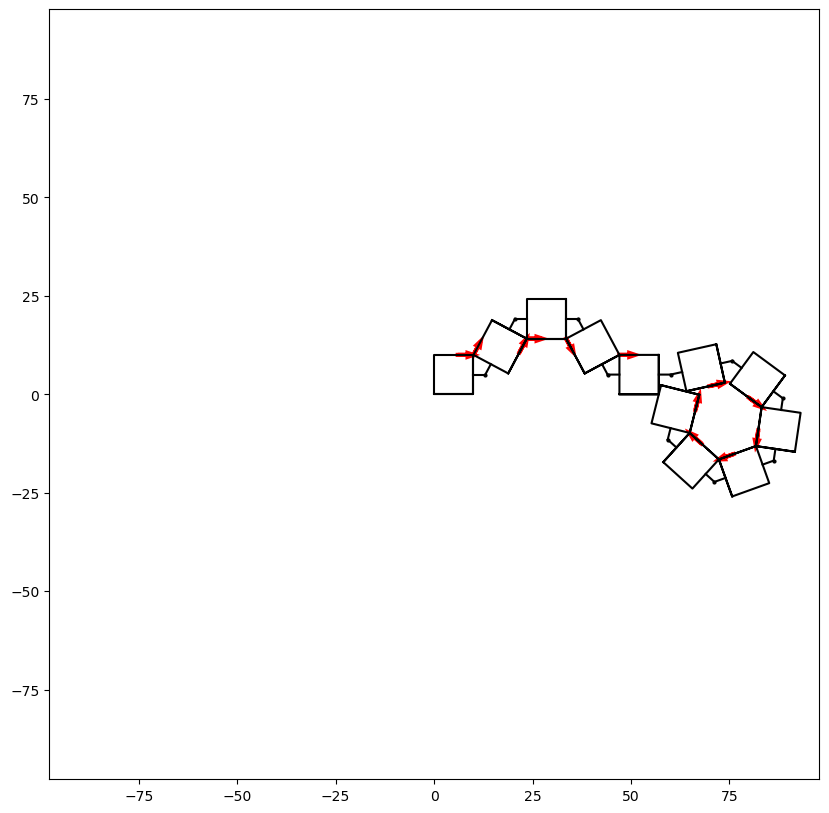

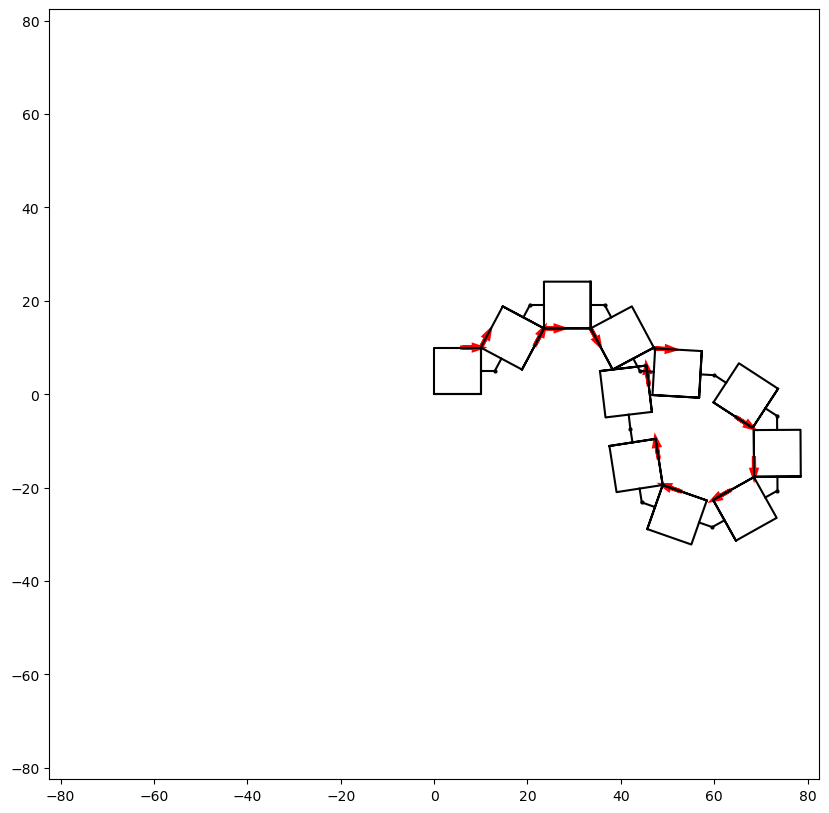

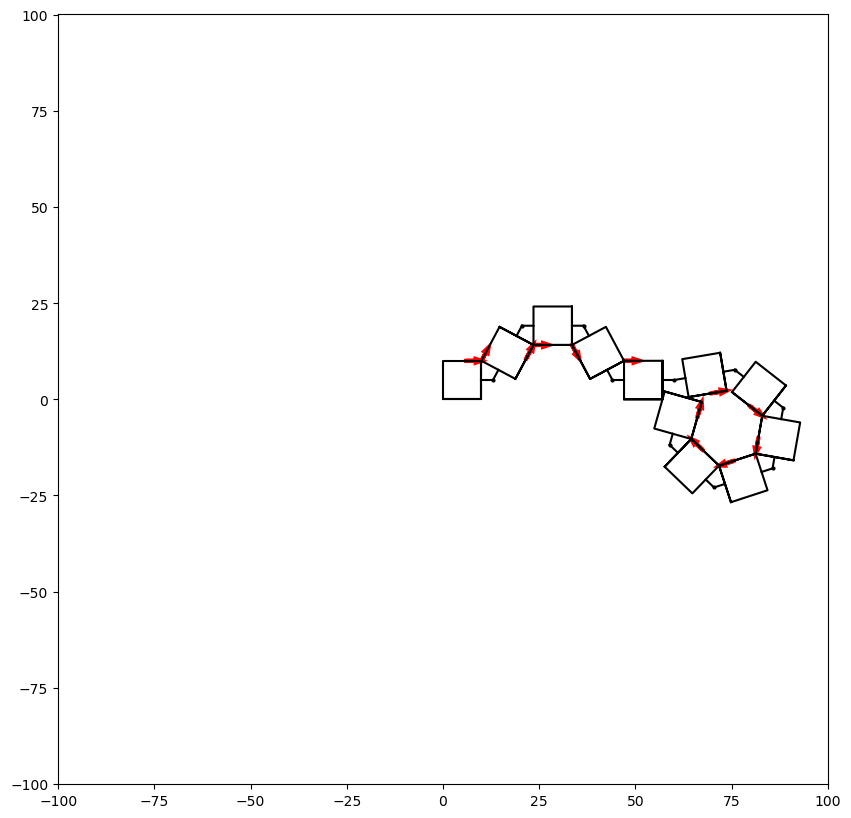

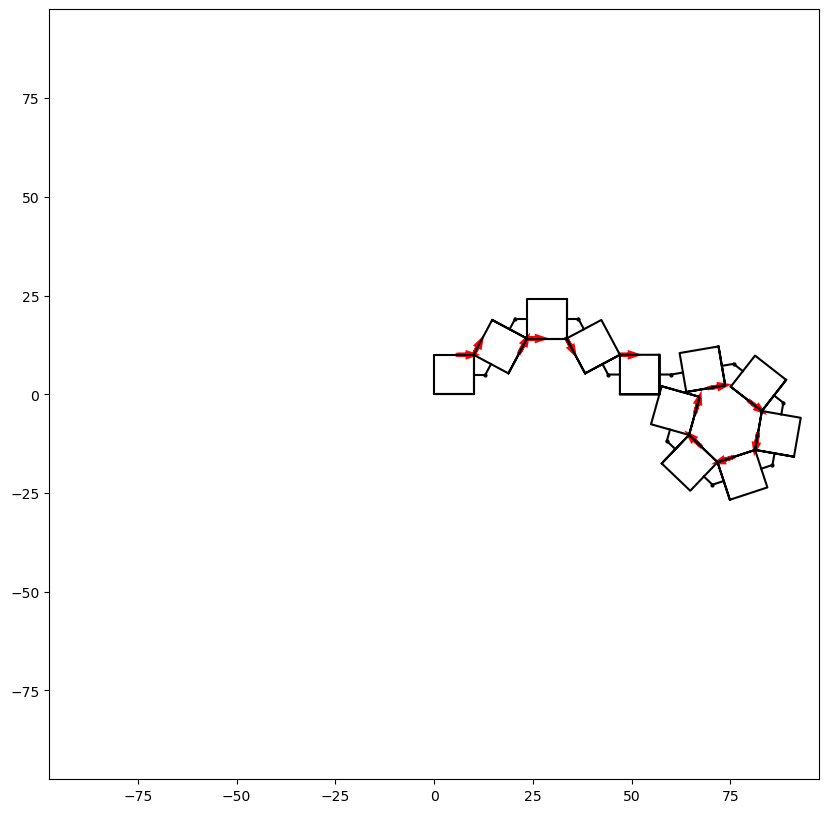

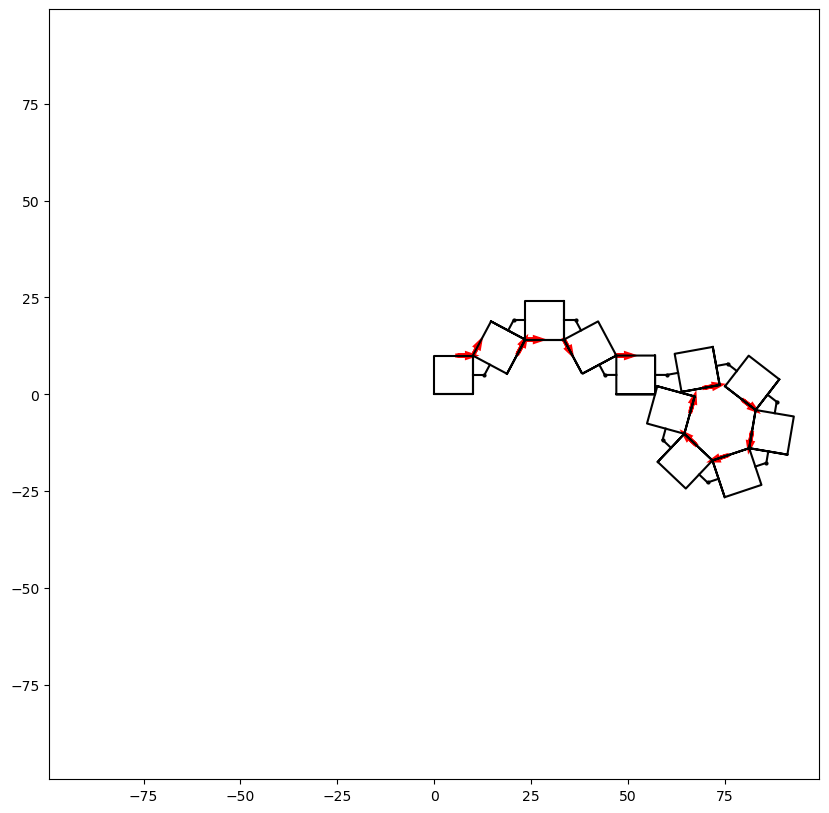

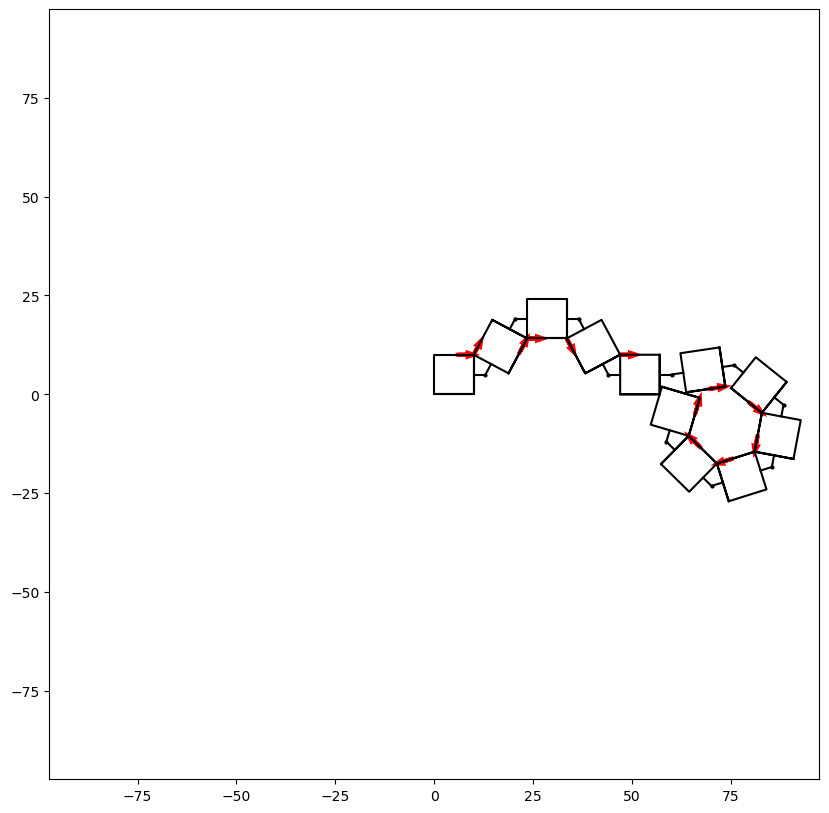

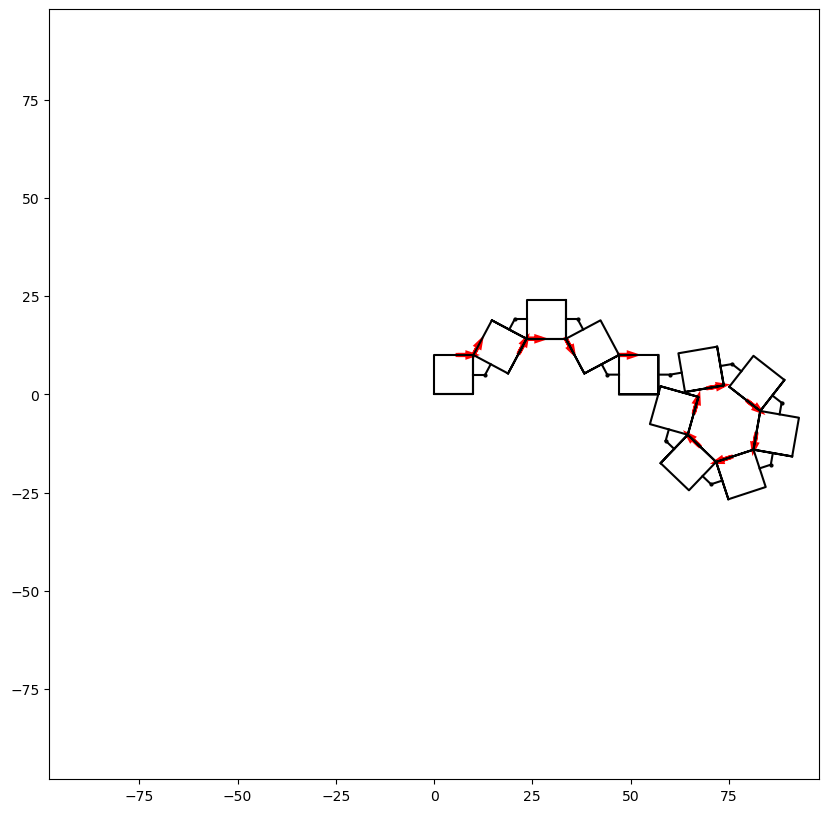

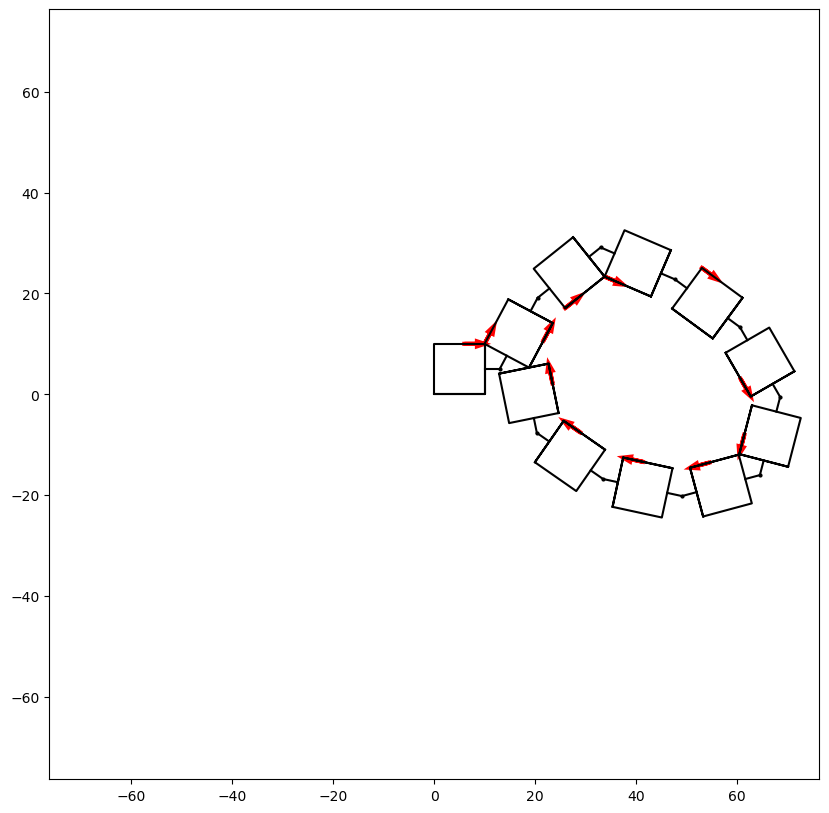

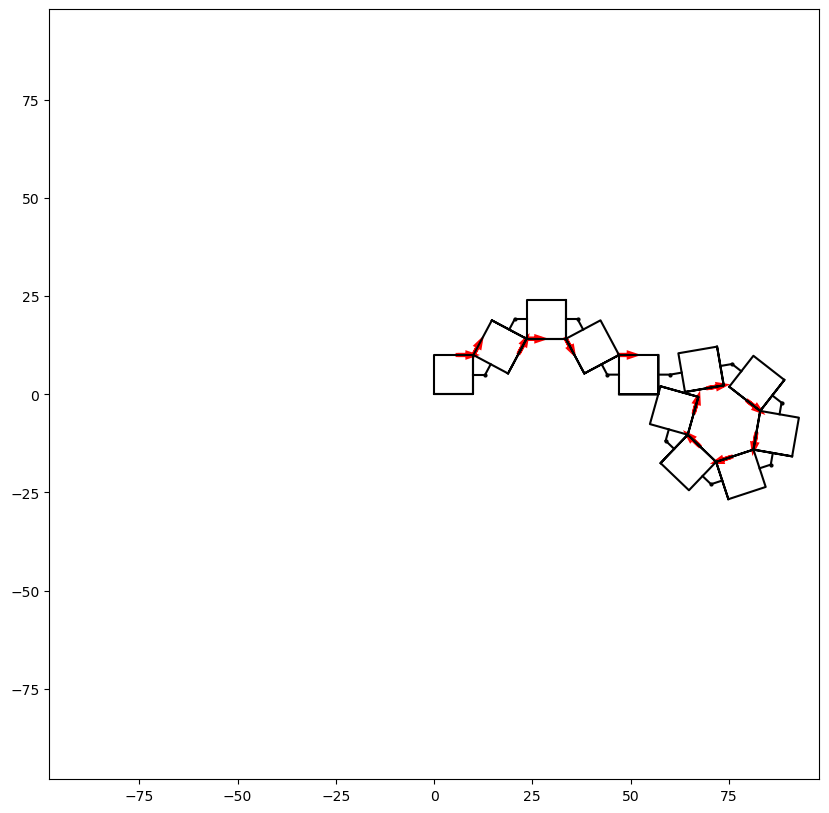

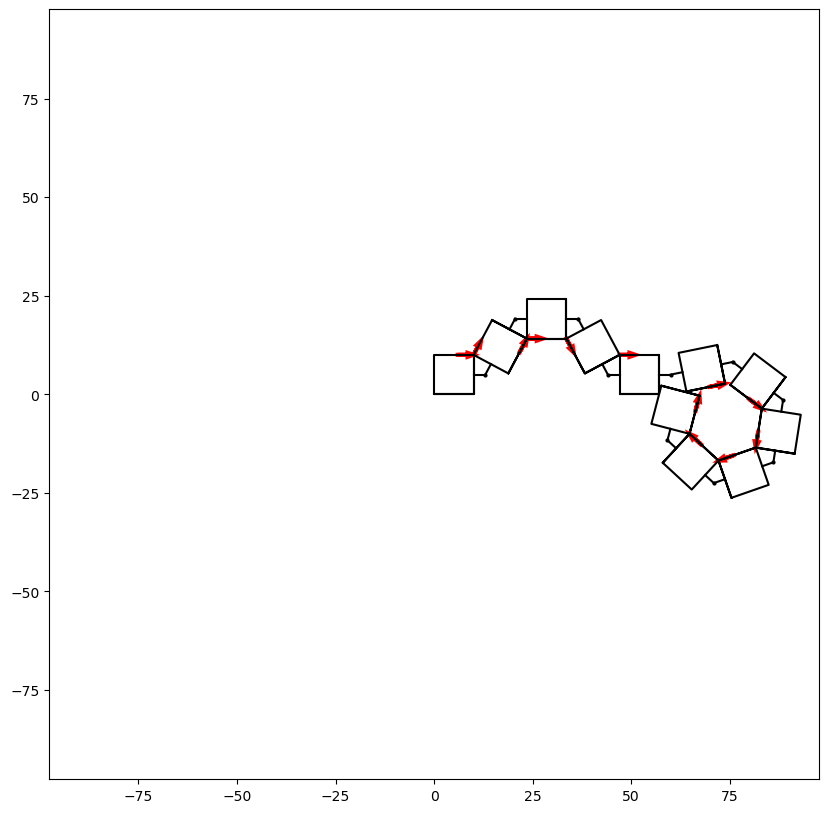

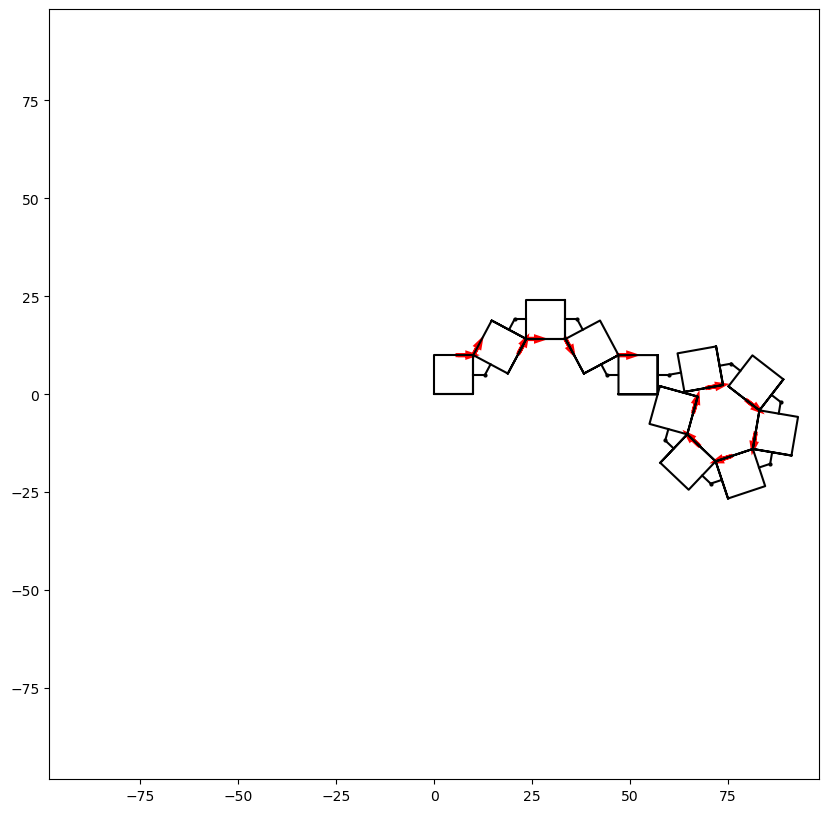

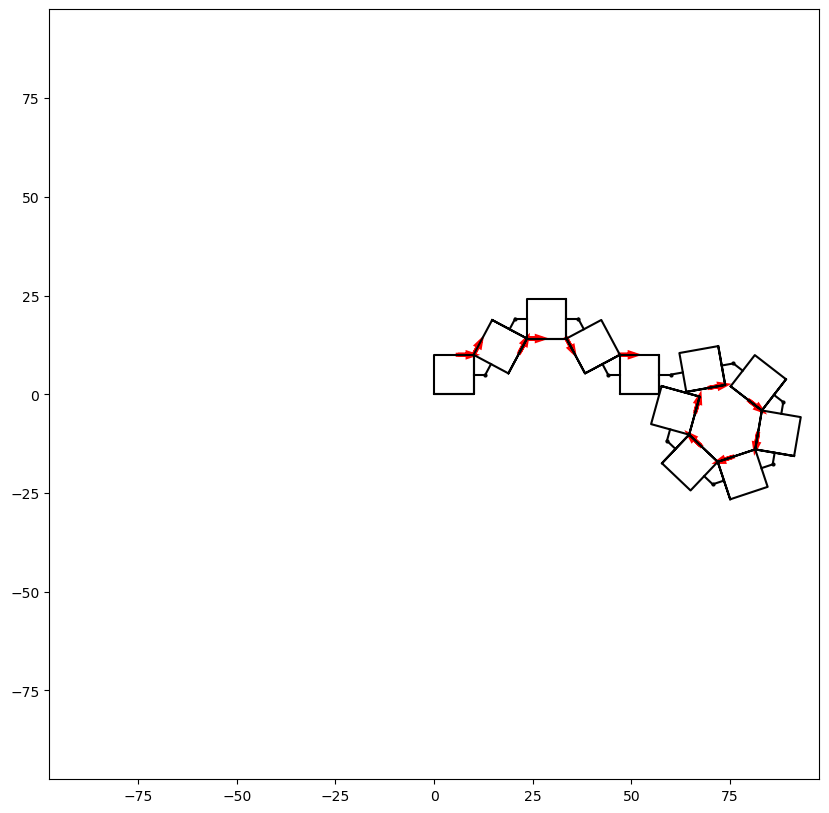

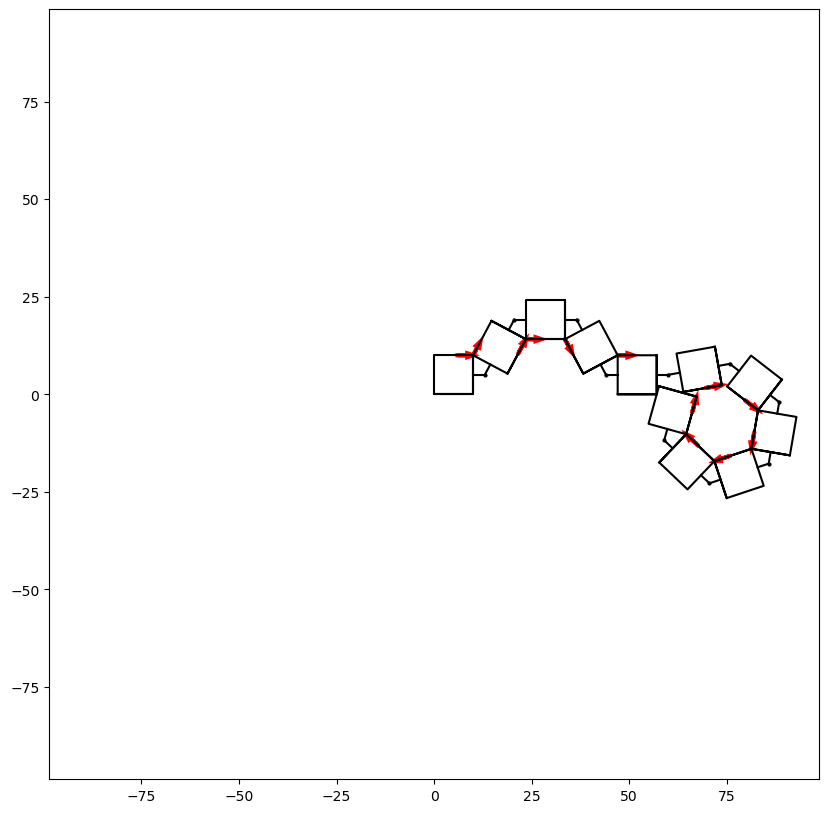

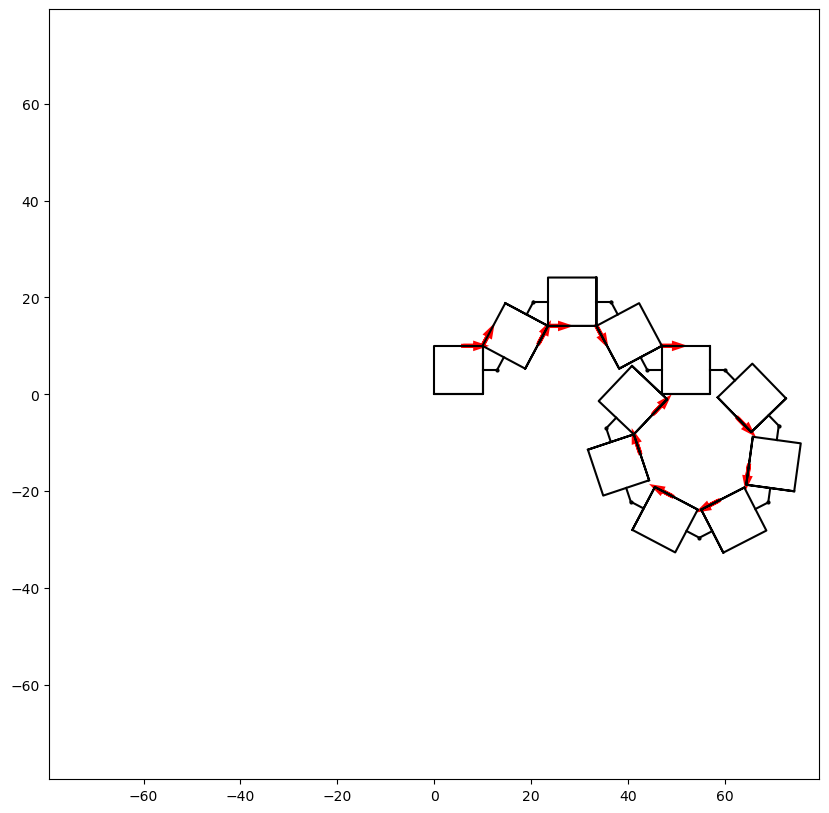

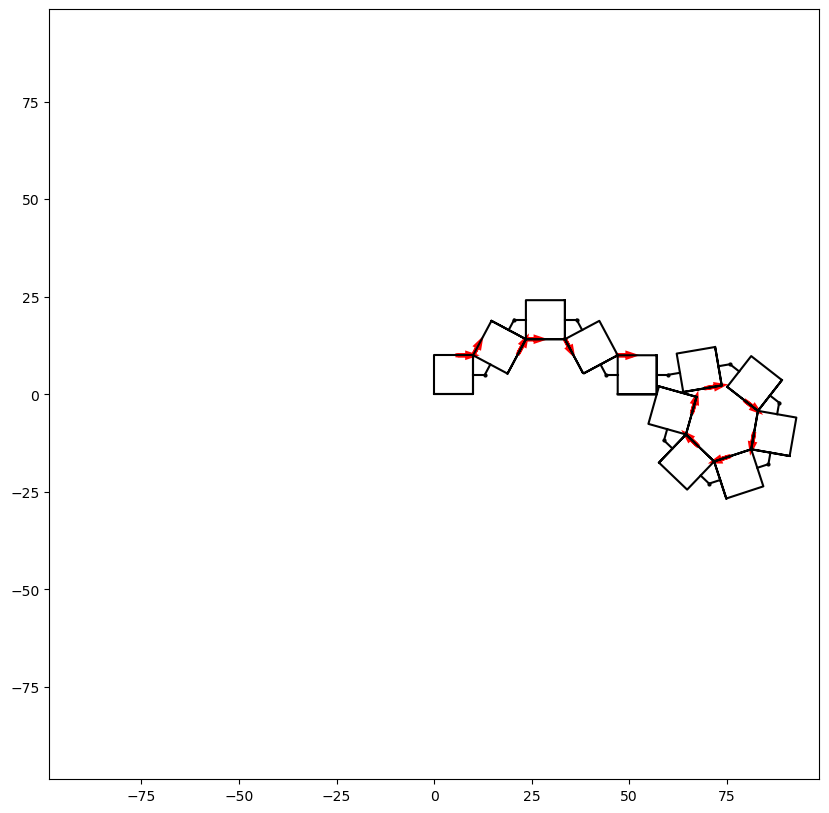

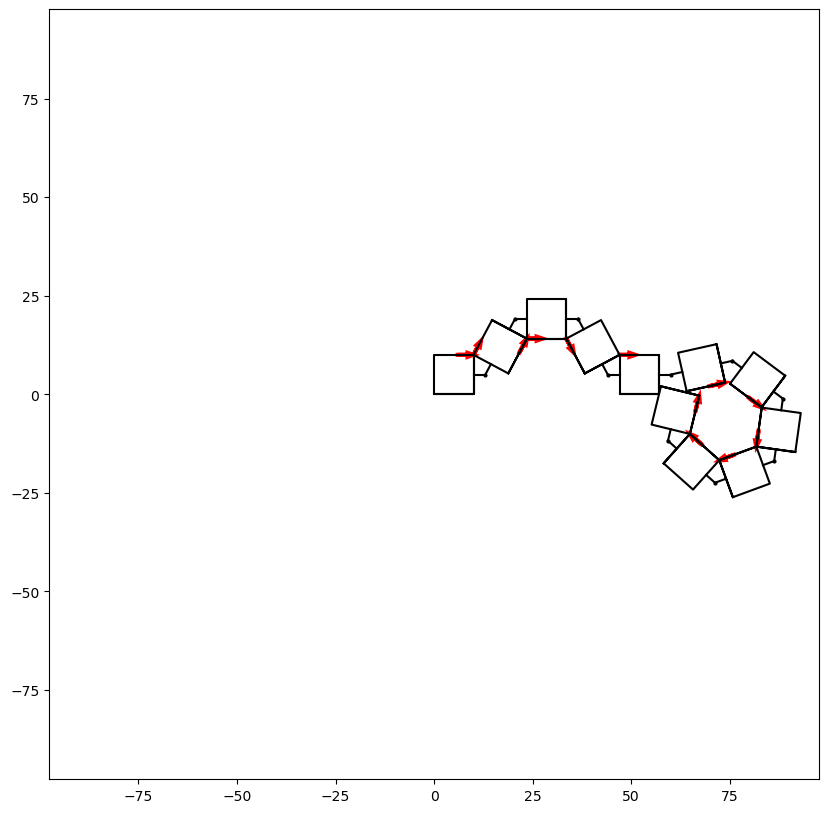

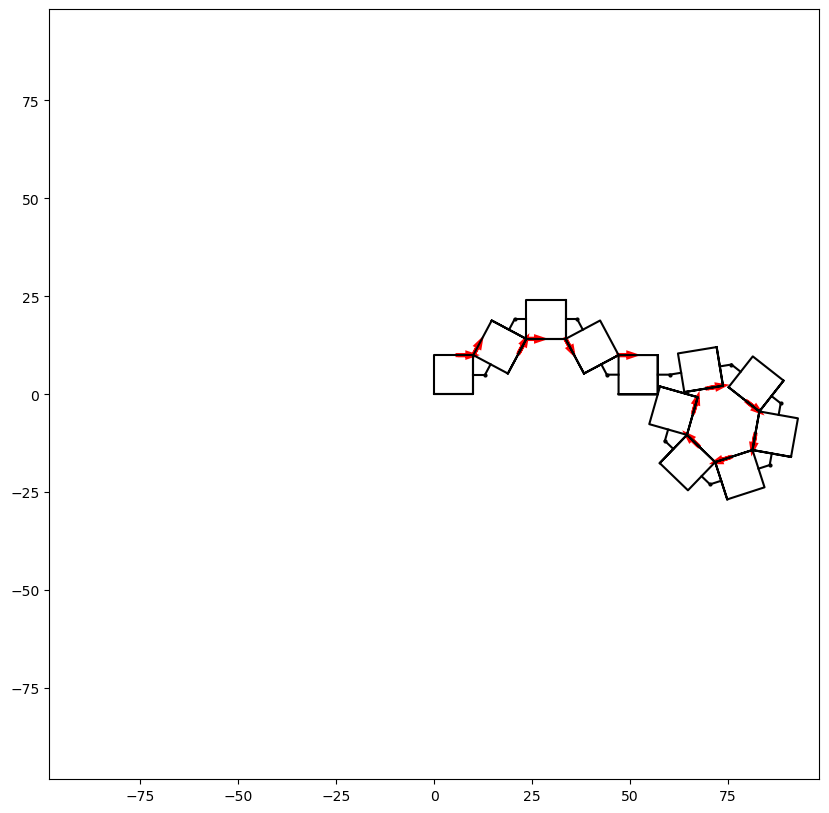

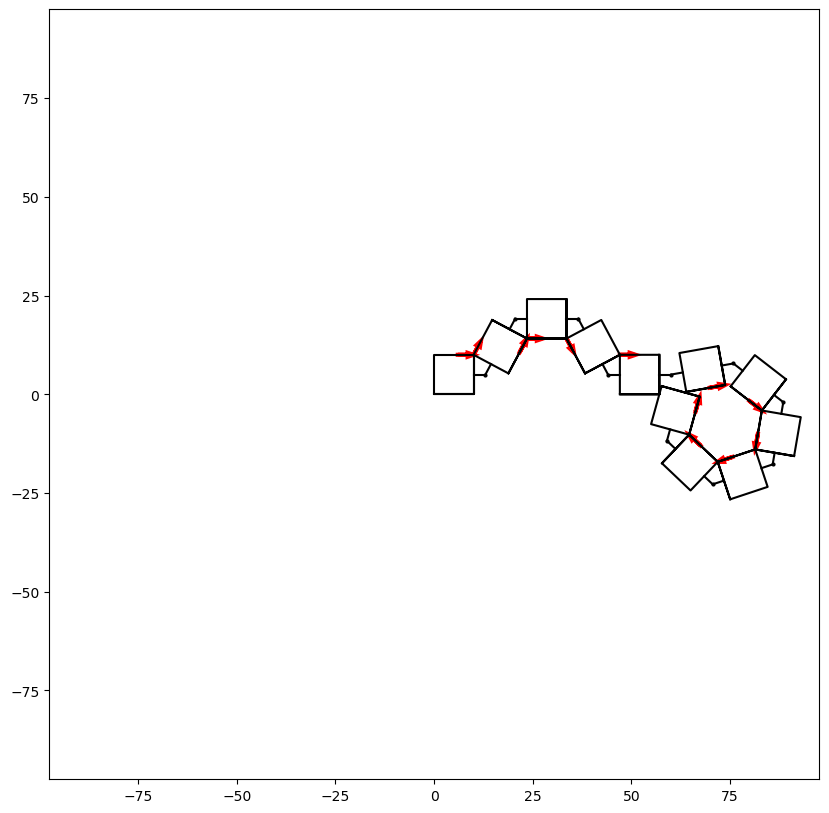

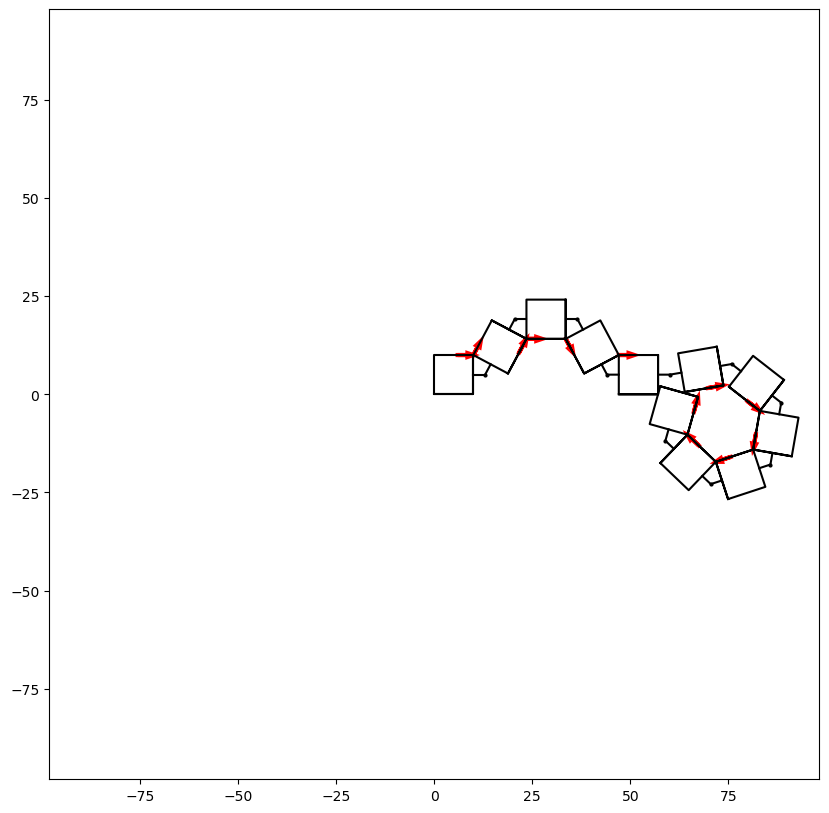

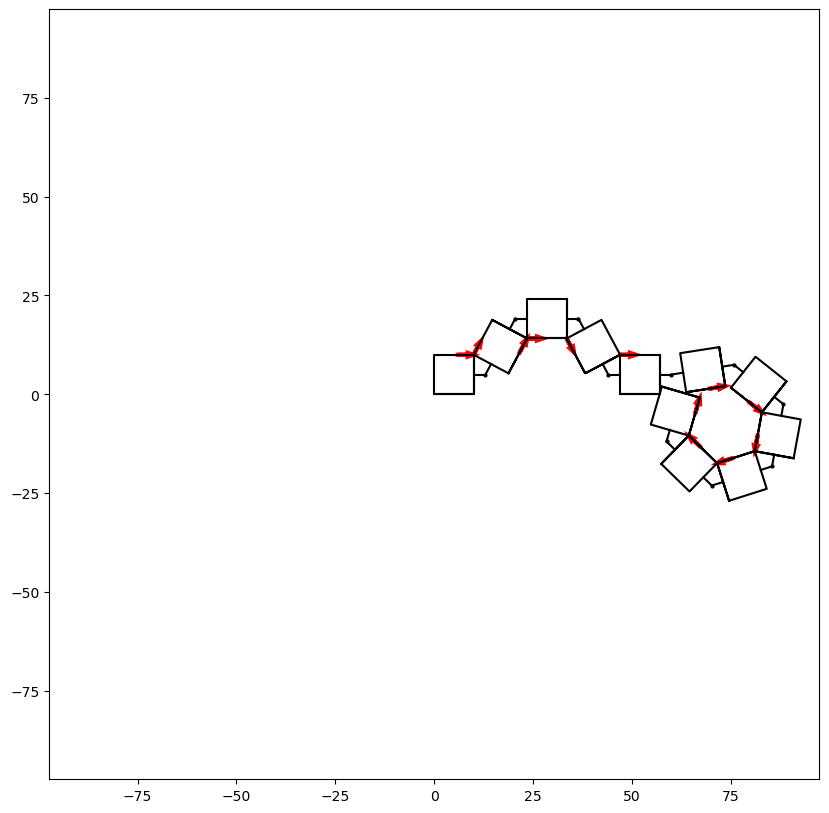

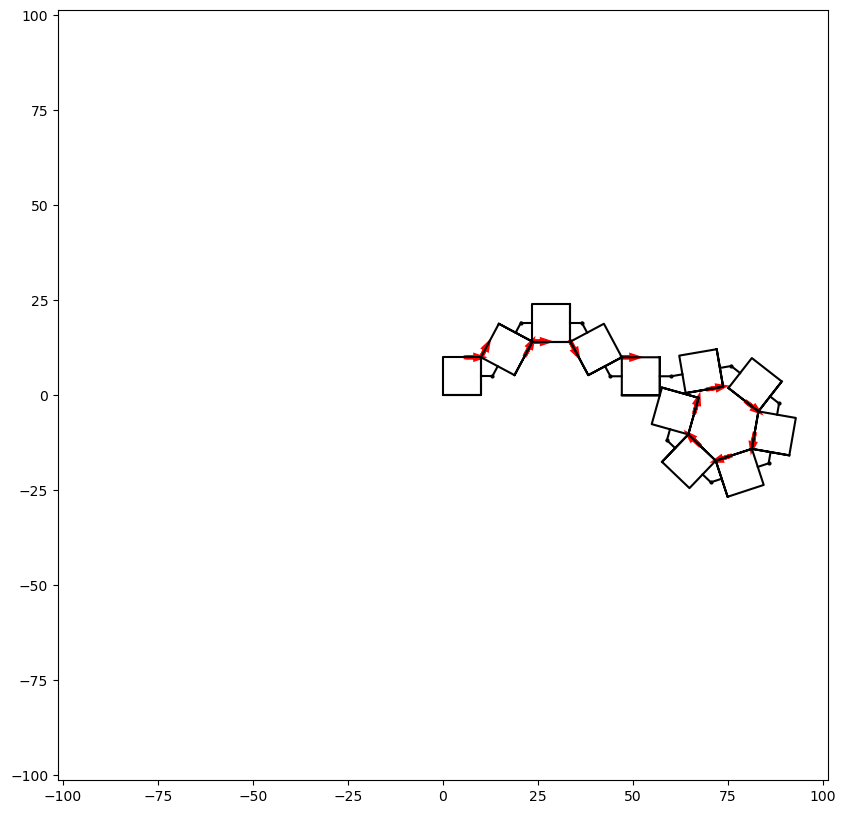

In [ ]:
# running these tests many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
numsim = 20
energy_gdmc = [[] for _ in range(numsim)]
energy_gdws = [[] for _ in range(numsim)]
energy_mc = [[] for _ in range(numsim)]
energy_ws = [[] for _ in range(numsim)]
for i in range(numsim):
    patch_arr_mc, shape_arr_mc, hinge_vec_mc, hinge_loc_mc, current_energy_mc, energy_mc[i] = sim.simulate_monteCarlo(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
    patch_arr_ws, shape_arr_ws, hinge_vec_ws, hinge_loc_ws, current_energy_ws, energy_ws[i] = sim.simulate_weightedSync(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
    
    patch_arr_gdmc, shape_arr_gdmc, hinge_vec_gdmc, hinge_loc_gdmc, current_energy_gdmc, energy_gdmc[i] = sim.simulate_greedyDescent(patch_arr_mc,shape_arr_mc,linelist,hinge_vec_mc, hinge_loc_mc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=1, ani_folder='tests')
    patch_arr_gdws, shape_arr_gdws, hinge_vec_gdws, hinge_loc_gdws, current_energy_gdws, energy_gdws[i] = sim.simulate_greedyDescent(patch_arr_ws,shape_arr_ws,linelist,hinge_vec_ws, hinge_loc_ws, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=2, ani_folder='tests')   
     

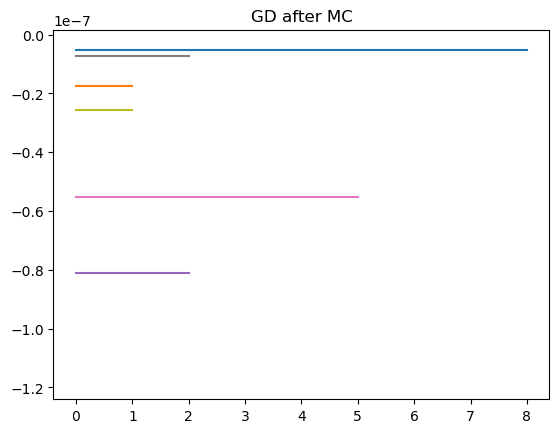

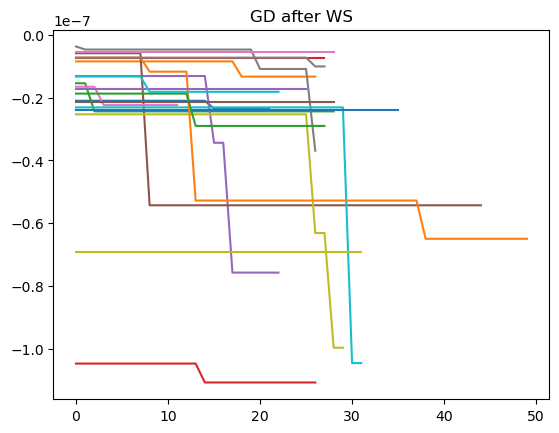

In [ ]:
for i in range(numsim):
    plt.plot(energy_gdmc[i])
    plt.title("GD after MC")
plt.show()
for i in range(numsim):
    plt.plot(energy_gdws[i])
    plt.title("GD after WS")
plt.show()